# Credit Risk Analysis — *Default of Credit Card Clients*
### Pipeline Preprocessing + Perbandingan Model — versi bersih & terstruktur

**Sumber data:** UCI Machine Learning Repository — *Default of Credit Card Clients* (ID **350**)
**URL:** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
**Paper asli:** Yeh, I. C., & Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* **Expert Systems with Applications, 36(2), 2473–2480.**
**Sitasi dataset:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H
**Lisensi:** CC BY 4.0

---

#### Konteks dataset (ringkasan dokumentasi resmi)
Berisi **30.000 nasabah kartu kredit di Taiwan**, data periode **April–September 2005**, dikumpulkan untuk membandingkan akurasi prediksi *probability of default* antar enam metode *data mining*. Variabel target: **gagal bayar pada bulan berikutnya** (`default payment next month`; **1 = gagal bayar, 0 = lancar**).

Terdapat **23 variabel penjelas** + `ID` + target:

| Kelompok | Kolom | Keterangan menurut dokumentasi |
|---|---|---|
| Demografi | `SEX` (X2) | 1 = laki-laki, 2 = perempuan |
| | `EDUCATION` (X3) | 1 = pascasarjana, 2 = universitas, 3 = SMA, 4 = lainnya |
| | `MARRIAGE` (X4) | 1 = menikah, 2 = lajang, 3 = lainnya |
| | `AGE` (X5) | umur (tahun) |
| Limit kredit | `LIMIT_BAL` (X1) | plafon kredit (NT$) — termasuk kredit individu **dan** keluarga/suplemen |
| Status bayar | `PAY_0`, `PAY_2`–`PAY_6` (X6–X11) | status pembayaran Sep→Apr 2005. **-1** = bayar tepat waktu; **1..9** = telat 1..≥9 bulan |
| Tagihan | `BILL_AMT1`–`BILL_AMT6` (X12–X17) | nominal tagihan (NT$), Sep→Apr 2005 |
| Pembayaran | `PAY_AMT1`–`PAY_AMT6` (X18–X23) | nominal pembayaran (NT$), Sep→Apr 2005 |

> **Catatan penting dari dokumentasi:** field *"Has Missing Values? → **No**"*. Artinya secara *resmi* tidak ada sel kosong. Namun pada **EDA** kita akan menemukan **nilai di luar skema yang didokumentasikan** (mis. `EDUCATION ∈ {0,5,6}`, `MARRIAGE = 0`, `PAY_* ∈ {-2, 0}`). Inilah *"missing / inkonsistensi tersembunyi"* yang menjadi **dasar** beberapa langkah preprocessing di bawah.

## 0. Ringkasan Alur Preprocessing & Alasannya

Tabel ringkas — **teknik → alasan dipakai → kaitan dengan karakteristik/dokumentasi dataset**:

| # | Teknik | Alasan dipakai | Kaitan dengan dataset (dokumentasi / EDA) |
|---|---|---|---|
| 1 | Drop `ID`, rename target, `PAY_0→PAY_1` | `ID` cuma identifier (bukan prediktor); penamaan konsisten | Dok.: `ID` ber-*role* "ID", bukan "Feature". Penamaan `PAY_0` ganjil (langsung lompat `PAY_2`) → diseragamkan jadi `PAY_1` |
| 2 | Hapus duplikat | Baris identik membiaskan model & melebih-hitung performa | EDA menemukan **35** baris duplikat persis |
| 3 | Nilai inkonsisten → NaN | Nilai di luar skema dokumentasi = kategori tak terdefinisi | Dok.: `EDUCATION` hanya {1–4}, `MARRIAGE` {1–3}; data nyata memuat 0/5/6 dan 0 |
| 4 | Split **sebelum** imputasi/scaling | Mencegah *data leakage* statistik test ke train | Praktik standar; modus, batas IQR, scaler **dihitung dari TRAIN saja** |
| 5 | **Imputasi KNN** | Mengisi kategori hilang dari k=5 tetangga termirip (sadar-konteks), bukan satu nilai global | Proporsi anomali kecil (`EDUCATION` 1,15%, `MARRIAGE` 0,18%); fitur di-scale dulu, fit TRAIN saja (bebas leakage), hasil dibulatkan ke kategori sah |
| 6 | Outlier capping (IQR / *winsorizing*) | Variabel uang sangat *skewed* & berekor panjang; capping menjaga ukuran sampel | `LIMIT_BAL` mencakup kredit keluarga → rentang sangat lebar; `BILL/PAY_AMT` (NT$) → nilai ekstrem |
| 7 | Feature extraction | 6 bulan tagihan/bayar/status saling berkorelasi → diringkas jadi sinyal risiko | Struktur *repeated measures* Apr–Sep 2005 (utilisasi, tren, jumlah telat, dsb.) |
| 8 | Encoding (OHE / Label) | Algoritma butuh input numerik; hindari urutan palsu pada nominal | `MARRIAGE` nominal → OHE; `SEX` biner → label |
| 9 | Binning `AGE` | Hubungan umur–risiko sering non-linear; segmentasi memudahkan interpretasi | `AGE` kontinu; kelompok usia lazim dipakai di *credit scoring* |
| 10 | Feature selection | Banyak fitur redundan (antar-bulan) → kurangi multikolinearitas & *overfit* | Korelasi antar `BILL_AMT` bulan berurutan sangat tinggi |
| 11 | Scaling (StandardScaler) | Skala antar fitur berbeda jauh (NT$ vs umur vs status) | Model berbasis jarak/gradien sensitif terhadap skala |
| 12 | Imbalance handling (**dipilih otomatis**, Step 11b) | Kelas *default* minoritas → model bias & recall rendah; teknik terbaik dipilih dari beberapa kandidat (SMOTE/Borderline/ADASYN/under-sampling/kombinasi) | EDA: hanya **±22%** *default* (rasio ±3,5 : 1) |

> **Catatan metodologis:** (1) **Imputasi KNN** — `StandardScaler` + `KNNImputer` di-*fit* pada TRAIN saja lalu dipakai untuk TEST sehingga **bebas *data leakage***. (2) **Imbalance handling diterapkan per-fold di dalam cross-validation**: pada jalur PyCaret lewat `fix_imbalance=True`, dan pada jalur manual lewat `imblearn.Pipeline` (sampler + estimator), sehingga sampel sintetis tidak "bocor" ke fold validasi dan **AUC train tetap diukur pada data asli** (estimasi *gap* jujur). **Test set tidak pernah di-resample.** (3) Teknik penyeimbang **dipilih otomatis** di Step 11b berdasarkan AUC, *gap* AUC train-test (< 10%), dan keseimbangan recall.

---
## 1. Instalasi & Import Library

In [ ]:
# Instalasi (uncomment bila belum terpasang)
# !pip install pandas numpy matplotlib seaborn scikit-learn
# !pip install imbalanced-learn pycaret openpyxl xlrd ucimlrepo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats      
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import (
    SelectKBest, f_classif, RFE
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.impute import KNNImputer
from sklearn.base import clone

from pycaret.classification import (
    setup, compare_models, evaluate_model, plot_model,
    finalize_model, predict_model, save_model, load_model
)

from sklearn.ensemble import *
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import *

# Imbalanced-learn: pipeline + sampler agar resampling hanya pada data latih (per-fold), bebas leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN

import time, joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42


In [2]:
def check_plot(df, variable):
    """Histogram + Q-Q plot + boxplot untuk satu kolom numerik."""
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30, kde=True)
    plt.title(f'Histogram - {variable}')

    plt.subplot(1, 3, 2)
    stats.probplot(df[variable].dropna(), dist="norm", plot=plt)
    plt.ylabel('Quantiles variabel')
    plt.title(f'Q-Q Plot - {variable}')

    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title(f'Boxplot - {variable}')
    plt.tight_layout()
    plt.show()


def find_outlier_boundary(df, variable, k=1.5):
    """Batas atas/bawah berdasarkan aturan IQR (Tukey)."""
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return upper, lower

---
## 2. Load Data

Pemuatan diutamakan lewat paket resmi **`ucimlrepo`** (reproducible, tanpa file lokal). Bila gagal (mis. tanpa internet), otomatis *fallback* ke file Excel `default of credit card clients.xls`. Baris pertama Excel adalah label `X1..X23` sehingga dibaca dengan `header=1`. Fungsi `standardize_columns` menyeragamkan nama kolom ke bentuk kanonik (`LIMIT_BAL`, `SEX`, `PAY_0`, ...).

In [3]:
def standardize_columns(df):
    xmap = {'X1':'LIMIT_BAL','X2':'SEX','X3':'EDUCATION','X4':'MARRIAGE','X5':'AGE',
            'X6':'PAY_0','X7':'PAY_2','X8':'PAY_3','X9':'PAY_4','X10':'PAY_5','X11':'PAY_6',
            'X12':'BILL_AMT1','X13':'BILL_AMT2','X14':'BILL_AMT3','X15':'BILL_AMT4',
            'X16':'BILL_AMT5','X17':'BILL_AMT6',
            'X18':'PAY_AMT1','X19':'PAY_AMT2','X20':'PAY_AMT3','X21':'PAY_AMT4',
            'X22':'PAY_AMT5','X23':'PAY_AMT6','Y':'default payment next month'}
    df = df.rename(columns={c: xmap.get(str(c), c) for c in df.columns})
    df.columns = [str(c).strip() for c in df.columns]
    # seragamkan nama kolom target apa pun variasinya
    for c in list(df.columns):
        norm = str(c).lower().replace('.', ' ').replace('_', ' ').strip()
        if norm == 'default payment next month':
            df = df.rename(columns={c: 'default payment next month'})
    return df


path = '..\Dataset\defaultCreditCardClients.xls'
dataset_raw = standardize_columns(pd.read_excel(path, header=1))
print(f'Dimensi: {dataset_raw.shape}')
dataset_raw.head()

Dimensi: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


---
# 3. Exploratory Data Analysis (EDA)

## 3.1 Struktur & tipe data

In [5]:
print('Bentuk:', dataset_raw.shape)
print('\nTipe data:')
print(dataset_raw.dtypes.value_counts())
dataset_raw.info()

Bentuk: (30000, 25)

Tipe data:
int64    25
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  in

Seluruh kolom bertipe **integer** — sesuai dokumentasi (*Feature Type: Integer, Real*). Variabel kategorik (`SEX`, `EDUCATION`, `MARRIAGE`) **disimpan sebagai angka berkode**, bukan teks. **→ Implikasi:** kategorik berkode angka tetap perlu *encoding* yang tepat (Step 8) agar model tidak menafsirkan kode sebagai besaran numerik.

## 3.2 Statistik deskriptif

In [6]:
dataset_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Perhatikan kolom uang (`LIMIT_BAL`, `BILL_AMT*`, `PAY_AMT*`): selisih **mean vs median** besar, nilai **maks** jauh di atas kuartil-3, dan terdapat **tagihan negatif** (kelebihan bayar/refund). Ini ciri distribusi **menceng kanan** dengan ekor panjang. **→ Implikasi:** perlu **penanganan outlier** (Step 6) dan **scaling** (Step 11).

## 3.3 Distribusi target — *class imbalance*

Distribusi target:
  Non-Default (0): 23,364  (77.88%)
  Default (1): 6,636  (22.12%)

Rasio imbalance (0:1) = 3.52 : 1


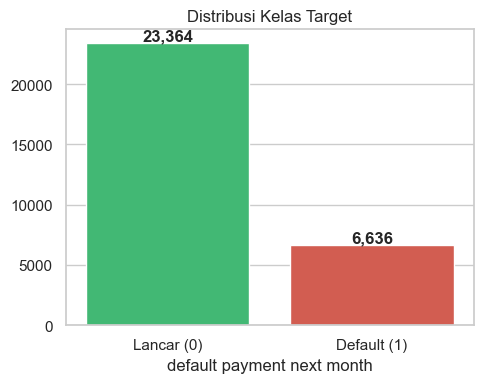

In [8]:
dist = dataset_raw['default payment next month'].value_counts().sort_index()
pct = (dist / dist.sum() * 100).round(2)
print('Distribusi target:')
for k in dist.index:
    label = 'Non-Default (0)' if k == 0 else 'Default (1)'
    print(f'  {label}: {dist[k]:,}  ({pct[k]}%)')
print(f'\nRasio imbalance (0:1) = {dist[0]/dist[1]:.2f} : 1')

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=dist.index, y=dist.values, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Lancar (0)', 'Default (1)'])
ax.set_title('Distribusi Kelas Target')
for i, v in enumerate(dist.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Hanya **±22% nasabah yang gagal bayar** (rasio ±3,5 : 1). Pada data timpang seperti ini, model cenderung "bermain aman" memprediksi mayoritas (lancar) sehingga *recall* kelas *default* — justru yang paling penting dalam manajemen risiko — menjadi rendah. **→ Implikasi:** perlu **imbalance handling** (Step 12) dan metrik evaluasi yang tepat (**AUC**, bukan akurasi).

## 3.4 Audit konsistensi kategori terhadap dokumentasi  *(temuan kunci)*

Dokumentasi mendefinisikan rentang nilai yang **terbatas**. Kita bandingkan nilai aktual dengan skema resmi.

In [9]:
allowed = {'SEX': {1, 2},
           'EDUCATION': {1, 2, 3, 4},
           'MARRIAGE': {1, 2, 3}}

for col, ok in allowed.items():
    vc = dataset_raw[col].value_counts().sort_index()
    luar = sorted(set(vc.index) - ok)
    print(f'{col:10s} nilai = {vc.to_dict()}')
    print(f'{"":10s} di luar dokumentasi -> {luar}\n')

# Audit status pembayaran PAY_* (dok.: -1, 1..9)
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
allowed_pay = set([-1] + list(range(1, 10)))
print('Audit PAY_* (nilai di luar dokumentasi {-1, 1..9}):')
for c in pay_cols:
    luar = sorted(set(dataset_raw[c].unique()) - allowed_pay)
    print(f'  {c:6s} -> {luar}')

SEX        nilai = {1: 11888, 2: 18112}
           di luar dokumentasi -> []

EDUCATION  nilai = {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
           di luar dokumentasi -> [0, 5, 6]

MARRIAGE   nilai = {0: 54, 1: 13659, 2: 15964, 3: 323}
           di luar dokumentasi -> [0]

Audit PAY_* (nilai di luar dokumentasi {-1, 1..9}):
  PAY_0  -> [-2, 0]
  PAY_2  -> [-2, 0]
  PAY_3  -> [-2, 0]
  PAY_4  -> [-2, 0]
  PAY_5  -> [-2, 0]
  PAY_6  -> [-2, 0]


In [10]:
# Seberapa besar porsi anomali pada EDUCATION & MARRIAGE?
pct_edu = 100 * dataset_raw['EDUCATION'].isin([0, 5, 6]).mean()
pct_mar = 100 * (dataset_raw['MARRIAGE'] == 0).mean()
print(f'Anomali EDUCATION (0,5,6): {pct_edu:.2f}%')
print(f'Anomali MARRIAGE  (0)    : {pct_mar:.2f}%')

Anomali EDUCATION (0,5,6): 1.15%
Anomali MARRIAGE  (0)    : 0.18%


**Temuan:**
- `EDUCATION` memuat **0, 5, 6** (≈ **1,15%**) dan `MARRIAGE` memuat **0** (≈ **0,18%**) — tidak ada di skema dokumentasi.
- `PAY_*` memuat **-2** dan **0** yang juga **tidak terdefinisi** pada paper (skala resmi hanya -1 dan 1..9). Interpretasi yang lazim di literatur: **-2** = tidak ada tagihan/lunas penuh, **0** = pemakaian kredit bergulir (*revolving*).

Walaupun dokumentasi menyatakan *"no missing values"*, nilai-nilai ini adalah **kategori tak terdefinisi / missing tersembunyi**. **→ Implikasi:** `EDUCATION`/`MARRIAGE` anomali ditandai **NaN lalu diimputasi** (Step 3 & 5). Nilai `PAY_*` **dipertahankan apa adanya** (membuangnya berisiko menghapus sinyal nyata) dan justru diringkas pada *feature extraction* (Step 7).

## 3.5 Duplikasi baris

In [27]:
col_instance = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

In [28]:
n_dup = dataset_raw[col_instance].duplicated().sum()
print(f'Jumlah baris duplikat persis: {n_dup}')
print(f'Porsi: {n_dup/len(dataset_raw)*100:.4f}%')

Jumlah baris duplikat persis: 35
Porsi: 0.1167%


Terdapat **35 baris identik**. Karena tiap baris seharusnya mewakili **satu nasabah unik**, duplikat ini kemungkinan artefak penggabungan data dan akan **membiaskan** distribusi serta melebih-hitung performa bila ikut ke test. **→ Implikasi:** **drop duplicates** (Step 2).

## 3.6 Distribusi & skewness fitur numerik → dasar outlier handling

In [12]:
money_cols = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]
skew_tbl = dataset_raw[money_cols + ['AGE']].skew().sort_values(ascending=False)
print('Skewness (|skew| > 1 = sangat menceng):')
print(skew_tbl.round(2))

Skewness (|skew| > 1 = sangat menceng):
PAY_AMT2     30.45
PAY_AMT3     17.22
PAY_AMT1     14.67
PAY_AMT4     12.90
PAY_AMT5     11.13
PAY_AMT6     10.64
BILL_AMT3     3.09
BILL_AMT5     2.88
BILL_AMT6     2.85
BILL_AMT4     2.82
BILL_AMT2     2.71
BILL_AMT1     2.66
LIMIT_BAL     0.99
AGE           0.73
dtype: float64


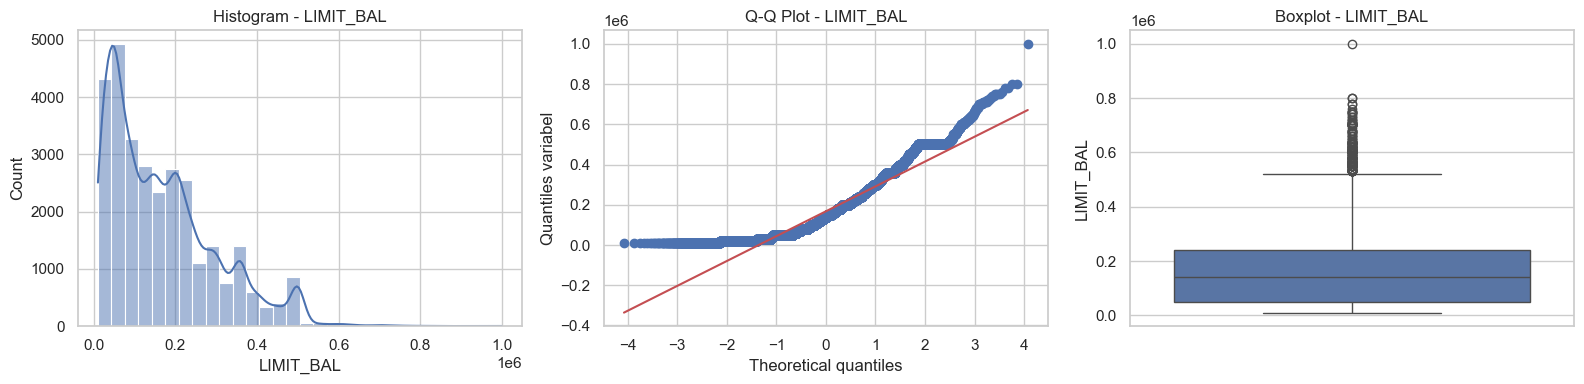

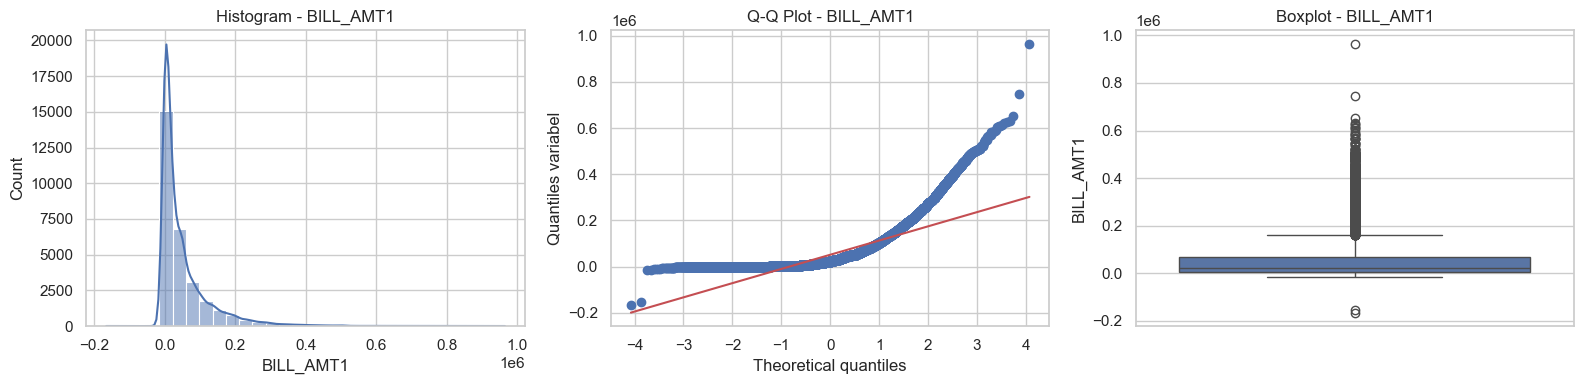

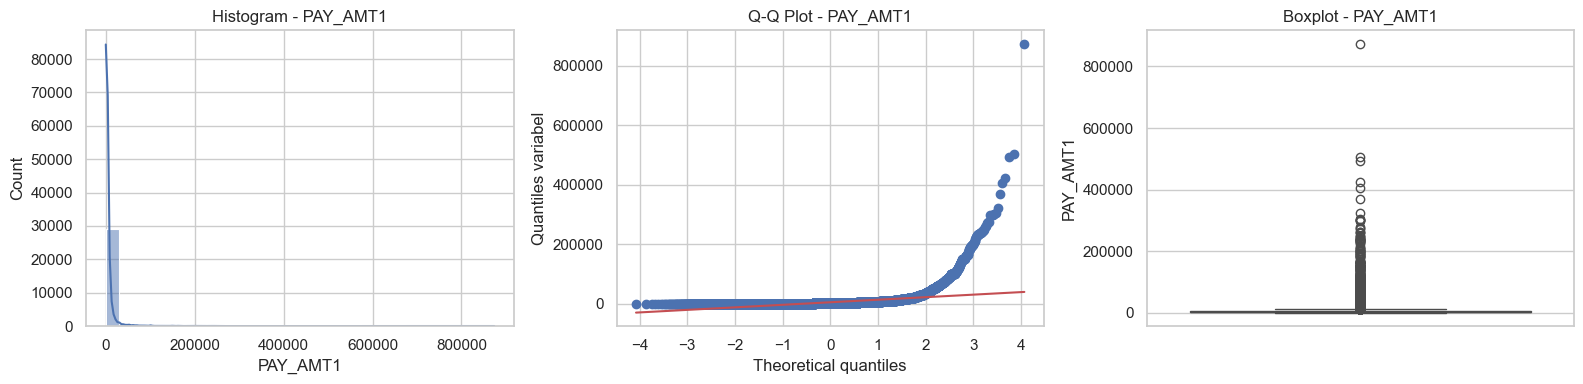

In [13]:
# Visual: kolom uang yang paling representatif
for col in ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']:
    check_plot(dataset_raw, col)

Histogram menumpuk di kiri, Q-Q plot melengkung jauh dari garis normal, dan boxplot menampilkan **banyak titik di luar pagar IQR**. `LIMIT_BAL` berekor lebar — konsisten dengan dokumentasi bahwa plafon **mencakup kredit keluarga/suplemen**, bukan hanya individu. **→ Implikasi:** **capping berbasis IQR** (Step 6) untuk meredam pengaruh ekstrem **tanpa membuang baris**, plus **scaling** (Step 11).

## 3.7 Korelasi antar fitur → dasar feature extraction & seleksi

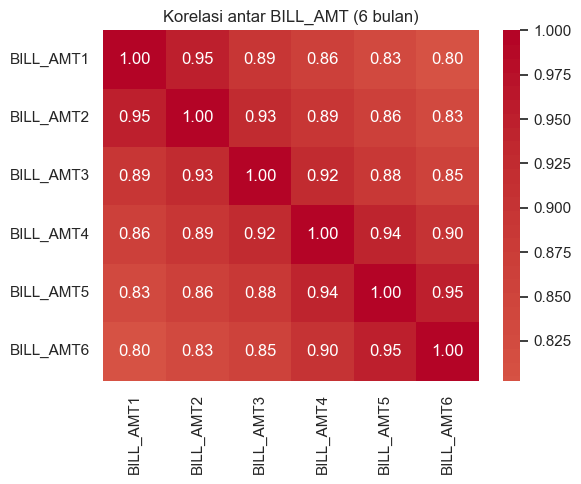

In [14]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
plt.figure(figsize=(6, 5))
sns.heatmap(dataset_raw[bill_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi antar BILL_AMT (6 bulan)')
plt.tight_layout()
plt.show()

In [40]:
dataset_raw.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month'],
      dtype='object')

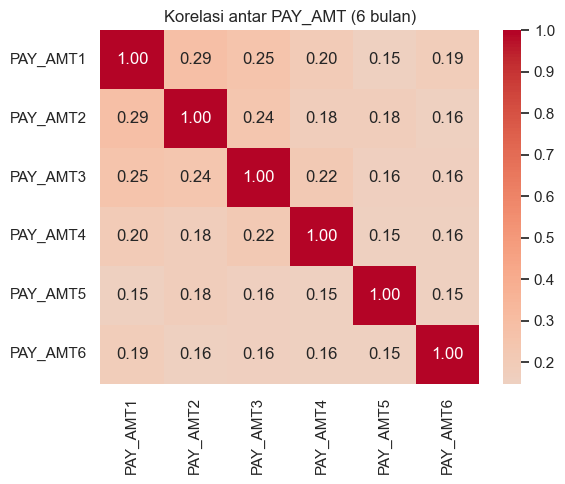

In [41]:
pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
plt.figure(figsize=(6, 5))
sns.heatmap(dataset_raw[pay_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi antar PAY_AMT (6 bulan)')
plt.tight_layout()
plt.show()

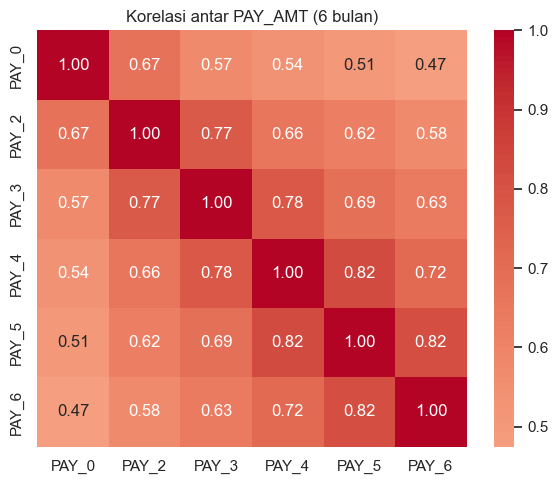

In [44]:
pay_categoric= ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
plt.figure(figsize=(6, 5))
sns.heatmap(dataset_raw[pay_categoric].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi antar PAY_AMT (6 bulan)')
plt.tight_layout()
plt.show()

Tagihan antar bulan yang berdekatan **berkorelasi sangat tinggi** (sering > 0,9) — wajar karena `BILL_AMT1..6` adalah **pengukuran berulang** atas nasabah yang sama selama 6 bulan (Apr–Sep 2005). Redundansi seperti ini menimbulkan **multikolinearitas**. **→ Implikasi:** (a) **ringkas** 6 bulan menjadi fitur agregat yang bermakna (Step 7); (b) **buang** fitur yang sangat berkorelasi & tak signifikan saat **feature selection** (Step 10).

## 3.8 Hubungan fitur dengan target

In [21]:
dataset_raw.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month'],
      dtype='object')

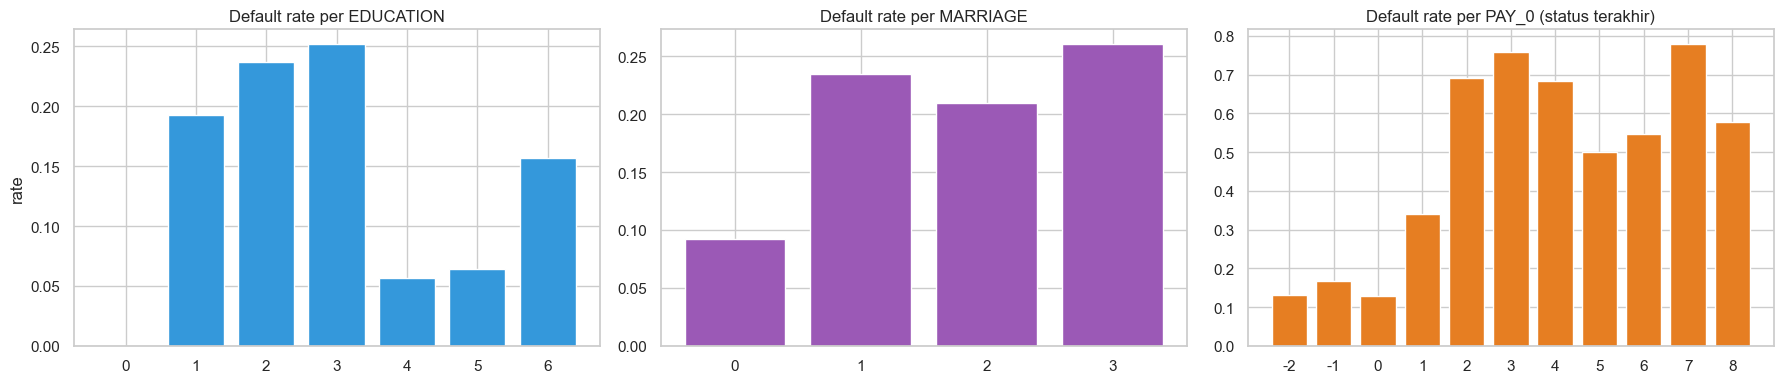

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

target_col = 'default payment next month'
# Default rate per EDUCATION
edu = dataset_raw.groupby('EDUCATION')[target_col].mean()
axes[0].bar(edu.index.astype(str), edu.values, color='#3498db')
axes[0].set_title('Default rate per EDUCATION'); axes[0].set_ylabel('rate')

# Default rate per MARRIAGE
mar = dataset_raw.groupby('MARRIAGE')[target_col].mean()
axes[1].bar(mar.index.astype(str), mar.values, color='#9b59b6')
axes[1].set_title('Default rate per MARRIAGE')

# Default rate per status bayar terkini (PAY_0)
p0 = dataset_raw.groupby('PAY_0')[target_col].mean()
axes[2].bar(p0.index.astype(str), p0.values, color='#e67e22')
axes[2].set_title('Default rate per PAY_0 (status terakhir)')
plt.tight_layout()
plt.show()

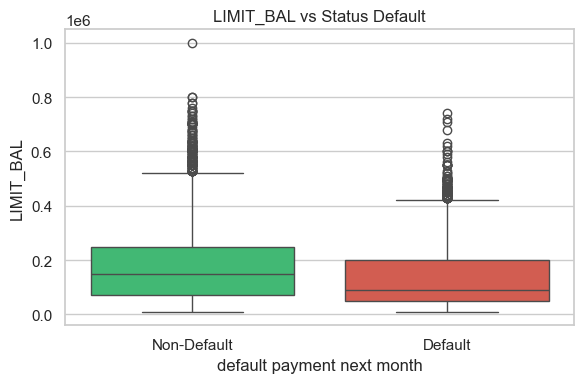

In [24]:
# LIMIT_BAL terhadap status default
plt.figure(figsize=(6, 4))
sns.boxplot(data=dataset_raw, x=target_col, y='LIMIT_BAL', palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.title('LIMIT_BAL vs Status Default')
plt.tight_layout()
plt.show()

**Pola yang terlihat:**
- **`PAY_0` paling diskriminatif:** makin besar keterlambatan terakhir, makin tinggi peluang *default* (naik tajam). Ini menguatkan pembuatan fitur **`MAX_DELAY`** dan **`N_LATE_PAYMENTS`** (Step 7).
- *Default rate* berbeda antar kelompok `EDUCATION`/`MARRIAGE` → keduanya **informatif** dan layak dipertahankan (setelah dibersihkan & di-*encode*).
- Nasabah *default* cenderung ber-`LIMIT_BAL` **lebih rendah** → `LIMIT_BAL` relevan, dan rasio **utilisasi kredit** (`AVG_UTIL_RATIO`, Step 7) berpotensi kuat.

## 3.9 Ringkasan temuan EDA → keputusan preprocessing

| Temuan EDA | Keputusan preprocessing | Step |
|---|---|---|
| `ID` non-prediktif; nama `PAY_0` ganjil | drop `ID`, rename target, `PAY_0→PAY_1` | 1 |
| 35 baris duplikat | hapus duplikat | 2 |
| `EDUCATION ∈{0,5,6}`, `MARRIAGE=0` (di luar dok.) | tandai NaN → **imputasi KNN** | 3, 5 |
| Statistik dihitung dari data → risiko leakage | split dulu, fit parameter dari TRAIN | 4 |
| Kolom uang menceng & berekor panjang | outlier capping IQR + scaling | 6, 11 |
| 6 bulan riwayat saling berkorelasi tinggi | feature extraction (agregasi) + seleksi | 7, 10 |
| Kategorik berkode angka | encoding (OHE / Label) | 8 |
| Target timpang (~22% default) | imbalance handling terpilih (per-fold) + evaluasi AUC & recall | 11b–12 |

---
# PREPROCESSING DATA

Urutan langkah mengikuti alur pada bagian 0. Setiap parameter yang "belajar" dari
data (modus, batas IQR, scaler, encoder) **di-*fit* hanya pada data TRAIN** lalu
diterapkan ke TEST — untuk mencegah *data leakage*.

## Step 1 — Eliminasi Variabel Non-Prediktif & Standarisasi Nama Kolom

**Mengapa:** `ID` hanyalah nomor urut nasabah (*role* "ID" pada dokumentasi) — tidak membawa informasi prediktif dan bisa membuat model menghafal baris. Kolom target diseragamkan menjadi `DEFAULT`. Penamaan `PAY_0` pada data ganjil (setelahnya langsung `PAY_2`); kita ubah menjadi `PAY_1` agar deret status bayar `PAY_1..PAY_6` konsisten.

In [4]:
dataset = dataset_raw.copy()

if 'ID' in dataset.columns:
    dataset.drop(columns=['ID'], inplace=True)

for cand in ['default payment next month', 'default.payment.next.month', 'Y']:
    if cand in dataset.columns:
        dataset.rename(columns={cand: 'DEFAULT'}, inplace=True)
        break

if 'PAY_0' in dataset.columns:
    dataset.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

print('Dimensi :', dataset.shape)
print('Kolom   :', list(dataset.columns))

Dimensi : (30000, 24)
Kolom   : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


## Step 2 — Handling Duplicate Data

**Mengapa (dari EDA 3.5):** terdapat 35 baris identik. Tiap baris seharusnya = satu nasabah unik, jadi duplikat dibuang agar tidak membiaskan distribusi maupun melebih-hitung performa.

In [5]:
n_dup = dataset.duplicated().sum()
print(f'Sebelum: {len(dataset):,} baris | duplikat: {n_dup}')

dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'Sesudah: {len(dataset):,} baris')

Sebelum: 30,000 baris | duplikat: 35
Sesudah: 29,965 baris


## Step 3 — Handling Missing / Inkonsistensi (tandai sebagai NaN)

**Mengapa (dari EDA 3.4):** meski dokumentasi menyatakan *"no missing values"*, `EDUCATION` memuat {0,5,6} dan `MARRIAGE` memuat {0} yang **di luar skema resmi**. Nilai ini diperlakukan sebagai *missing tersembunyi*: ditandai `NaN` lebih dulu, **lalu** diimputasi **setelah** split (Step 5) agar tidak bocor. Nilai `PAY_*` (-2, 0) **dibiarkan** karena membawa sinyal nyata.

In [7]:
print('Sebelum penandaan:')
print('  EDUCATION:', dataset['EDUCATION'].value_counts().sort_index().to_dict())
print('  MARRIAGE :', dataset['MARRIAGE'].value_counts().sort_index().to_dict())

dataset['EDUCATION'] = dataset['EDUCATION'].apply(lambda x: np.nan if x in [0, 5, 6] else x)
dataset['MARRIAGE']  = dataset['MARRIAGE'].apply(lambda x: np.nan if x == 0 else x)

print('\nSesudah penandaan (nilai inkonsisten -> NaN):')
print('  EDUCATION:', dataset['EDUCATION'].value_counts(dropna=False).sort_index().to_dict())
print('  MARRIAGE :', dataset['MARRIAGE'].value_counts(dropna=False).sort_index().to_dict())
print(f'\nNaN EDUCATION: {dataset["EDUCATION"].isna().sum()} | NaN MARRIAGE: {dataset["MARRIAGE"].isna().sum()}')

Sebelum penandaan:
  EDUCATION: {1.0: 10563, 2.0: 14019, 3.0: 4915, 4.0: 123}
  MARRIAGE : {1.0: 13643, 2.0: 15945, 3.0: 323}

Sesudah penandaan (nilai inkonsisten -> NaN):
  EDUCATION: {1.0: 10563, 2.0: 14019, 3.0: 4915, 4.0: 123, nan: 345}
  MARRIAGE : {1.0: 13643, 2.0: 15945, 3.0: 323, nan: 54}

NaN EDUCATION: 345 | NaN MARRIAGE: 54


## Step 4 — Train–Test Split (stratified, 70/30)

**Mengapa:** split dilakukan **sebelum** imputasi, capping outlier, dan scaling. Semua parameter tersebut akan dihitung **hanya dari TRAIN** lalu diterapkan ke TEST → mencegah *data leakage*. `stratify=y` menjaga proporsi kelas (≈22% default) tetap sama di kedua set meski datanya timpang.

In [8]:
X = dataset.drop(columns=['DEFAULT'])
y = dataset['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print(f'TRAIN : {X_train.shape[0]:,} baris')
print(f'TEST  : {X_test.shape[0]:,} baris')
print('\nProporsi kelas TRAIN:'); print(y_train.value_counts(normalize=True).round(4).to_dict())
print('Proporsi kelas TEST :'); print(y_test.value_counts(normalize=True).round(4).to_dict())

TRAIN : 20,975 baris
TEST  : 8,990 baris

Proporsi kelas TRAIN:
{0: 0.7787, 1: 0.2213}
Proporsi kelas TEST :
{0: 0.7788, 1: 0.2212}


## Step 5 — Imputasi Missing Value (**KNN Imputation**)

**Mengapa KNN:** `EDUCATION`/`MARRIAGE` yang bernilai tak terdefinisi (sudah ditandai `NaN` di Step 3) diimputasi dengan **K-Nearest Neighbors Imputer**. Alih-alih satu nilai global (modus), KNN mengisi tiap baris kosong dari **k=5 tetangga termiripnya** berdasarkan seluruh fitur prediktor lain, sehingga imputasi bersifat **sadar-konteks** (mempertimbangkan limit, umur, riwayat tagihan/bayar, dll.) dan biasanya lebih representatif terhadap struktur lokal data.

**Cara kerja & anti-leakage:**
- KNN berbasis **jarak**, maka semua fitur prediktor di-*scale* dulu (`StandardScaler`) supaya tidak ada fitur berskala besar (mis. `LIMIT_BAL` dalam NT$) yang mendominasi perhitungan jarak.
- `StandardScaler` dan `KNNImputer` **di-*fit* hanya pada TRAIN**, lalu dipakai untuk men-*transform* TRAIN dan TEST. Statistik TEST tidak pernah ikut dilihat sehingga **bebas *data leakage***.
- `weights='distance'` artinya tetangga yang lebih dekat berkontribusi lebih besar pada nilai imputasi.
- Hasil imputasi di-*inverse transform* kembali ke skala asli, lalu untuk kolom kategorik (`EDUCATION`, `MARRIAGE`) nilainya **dibulatkan dan dibatasi (clip)** ke rentang sah dokumentasi (`EDUCATION` pada {1..4}, `MARRIAGE` pada {1..3}) agar tetap berupa kategori valid.
- `scaler_knn`, `knn_imputer`, daftar kolom konteks, dan rentang valid **disimpan sebagai artefak** untuk dipakai ulang saat inferensi. Modus keseluruhan TRAIN (`fallback_*`) tetap disimpan sebagai jaring pengaman.


In [9]:
# --- Imputasi KNN (bebas leakage: scaler & imputer di-fit pada TRAIN saja) ---
cols_with_na = ['EDUCATION', 'MARRIAGE']                    # kolom ber-NaN (ditandai di Step 3)
valid_ranges = {'EDUCATION': (1, 4), 'MARRIAGE': (1, 3)}     # rentang kategori sah (dokumentasi)

# Seluruh fitur prediktor dipakai sebagai konteks jarak KNN
knn_feature_columns = X_train.columns.tolist()

print('NaN sebelum imputasi (TRAIN):', X_train[cols_with_na].isna().sum().to_dict())
print('NaN sebelum imputasi (TEST) :', X_test[cols_with_na].isna().sum().to_dict())

# 1) Scaling untuk jarak (fit TRAIN saja). StandardScaler mempertahankan posisi NaN.
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train[knn_feature_columns])
X_test_scaled  = scaler_knn.transform(X_test[knn_feature_columns])

# 2) KNN Imputer (fit TRAIN saja): k=5, bobot berdasarkan jarak
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_imp = knn_imputer.fit_transform(X_train_scaled)
X_test_imp  = knn_imputer.transform(X_test_scaled)

# 3) Kembalikan ke skala asli
X_train_inv = pd.DataFrame(scaler_knn.inverse_transform(X_train_imp),
                           columns=knn_feature_columns, index=X_train.index)
X_test_inv  = pd.DataFrame(scaler_knn.inverse_transform(X_test_imp),
                           columns=knn_feature_columns, index=X_test.index)

# 4) Tulis balik HANYA kolom yang tadinya NaN; bulatkan & clip ke kategori sah
for col in cols_with_na:
    lo, hi = valid_ranges[col]
    X_train[col] = X_train_inv[col].round().clip(lo, hi).astype(int)
    X_test[col]  = X_test_inv[col].round().clip(lo, hi).astype(int)

# 5) Jaring pengaman: modus keseluruhan TRAIN (dipakai juga saat inferensi)
fallback_education = int(X_train['EDUCATION'].mode().iloc[0])
fallback_marriage  = int(X_train['MARRIAGE'].mode().iloc[0])

# Validasi rentang sesuai dokumentasi
assert set(X_train['EDUCATION'].unique()) <= {1, 2, 3, 4}
assert set(X_test['EDUCATION'].unique())  <= {1, 2, 3, 4}
assert set(X_train['MARRIAGE'].unique())  <= {1, 2, 3}
assert set(X_test['MARRIAGE'].unique())   <= {1, 2, 3}

print('\nNaN setelah imputasi -> TRAIN:',
      int(X_train[cols_with_na].isna().sum().sum()),
      '| TEST:', int(X_test[cols_with_na].isna().sum().sum()))
print(f'Fallback (modus TRAIN) -> EDUCATION={fallback_education}, MARRIAGE={fallback_marriage}')
print('Distribusi EDUCATION (TRAIN):', X_train['EDUCATION'].value_counts().sort_index().to_dict())
print('Distribusi MARRIAGE  (TRAIN):', X_train['MARRIAGE'].value_counts().sort_index().to_dict())


NaN sebelum imputasi (TRAIN): {'EDUCATION': 251, 'MARRIAGE': 43}
NaN sebelum imputasi (TEST) : {'EDUCATION': 94, 'MARRIAGE': 11}

NaN setelah imputasi -> TRAIN: 0 | TEST: 0
Fallback (modus TRAIN) -> EDUCATION=2, MARRIAGE=2
Distribusi EDUCATION (TRAIN): {1: 7470, 2: 10031, 3: 3394, 4: 80}
Distribusi MARRIAGE  (TRAIN): {1: 9505, 2: 11246, 3: 224}


## Step 6 — Outlier Handling (IQR Capping / *Winsorizing*)

**Mengapa (dari EDA 3.2 & 3.6):** kolom uang sangat menceng dengan ekor panjang (`LIMIT_BAL` lebar karena memuat kredit keluarga). Dipilih **capping**, bukan *trimming* (drop), agar **ukuran sampel tetap utuh** — penting karena kelas default sudah minoritas. Batas atas/bawah memakai aturan IQR (1,5×) dan **dihitung dari TRAIN**, lalu diterapkan ke TRAIN & TEST dengan batas yang sama.

In [10]:
X_train_processed = X_train.copy()
X_test_processed  = X_test.copy()

continuous_features = ['LIMIT_BAL', 'AGE'] + \
    [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]

outlier_boundaries = {}   # disimpan untuk inference (Step 18)
rows = []
for col in continuous_features:
    upper, lower = find_outlier_boundary(X_train_processed, col)
    outlier_boundaries[col] = (float(lower), float(upper))

    # hitung outlier SEBELUM capping (pakai snapshot TRAIN agar tetap akurat saat re-run)
    n_out = int(((X_train[col] > upper) | (X_train[col] < lower)).sum())

    X_train_processed[col] = np.clip(X_train_processed[col], lower, upper)
    X_test_processed[col]  = np.clip(X_test_processed[col],  lower, upper)
    rows.append({'Fitur': col, 'Lower': round(lower, 1), 'Upper': round(upper, 1), 'Outliers(TRAIN)': n_out})

print(pd.DataFrame(rows).to_string(index=False))

    Fitur     Lower    Upper  Outliers(TRAIN)
LIMIT_BAL -235000.0 525000.0              117
      AGE       8.5     60.5              196
BILL_AMT1  -92462.0 163686.0             1653
BILL_AMT2  -89095.5 156588.5             1673
BILL_AMT3  -83659.2 146830.8             1720
BILL_AMT4  -76198.5 133397.5             1811
BILL_AMT5  -71058.0 123278.0             1883
BILL_AMT6  -70733.8 121220.2             1872
 PAY_AMT1   -5014.2  11023.8             1939
 PAY_AMT2   -5300.0  11180.0             1893
 PAY_AMT3   -5752.5  10651.5             1827
 PAY_AMT4   -5329.5   9682.5             2106
 PAY_AMT5   -5311.8   9606.2             2086
 PAY_AMT6   -5625.0   9775.0             2078


LIMIT_BAL sebelum IQR Capping:


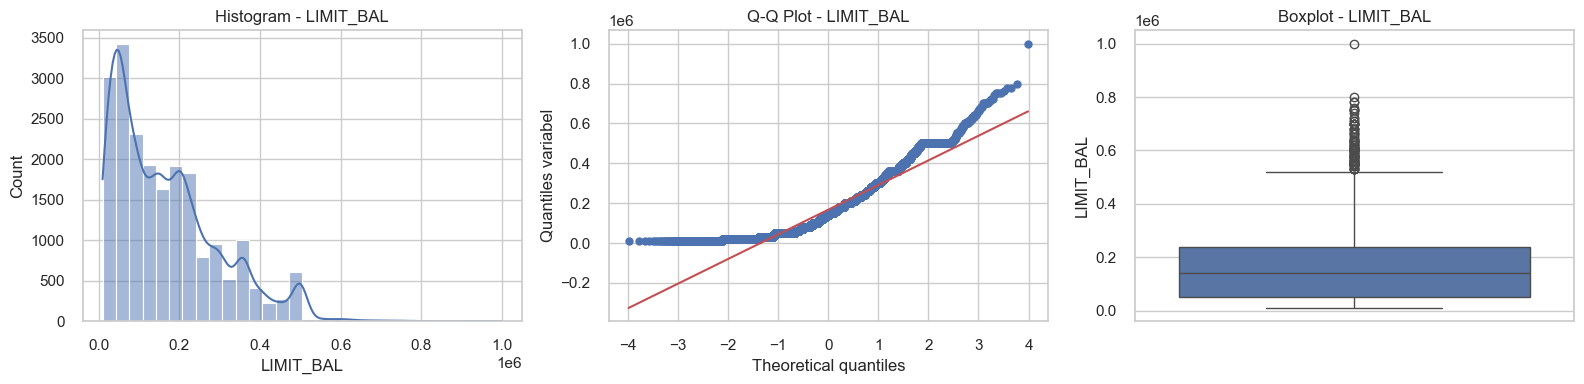

LIMIT_BAL sesudah IQR Capping:


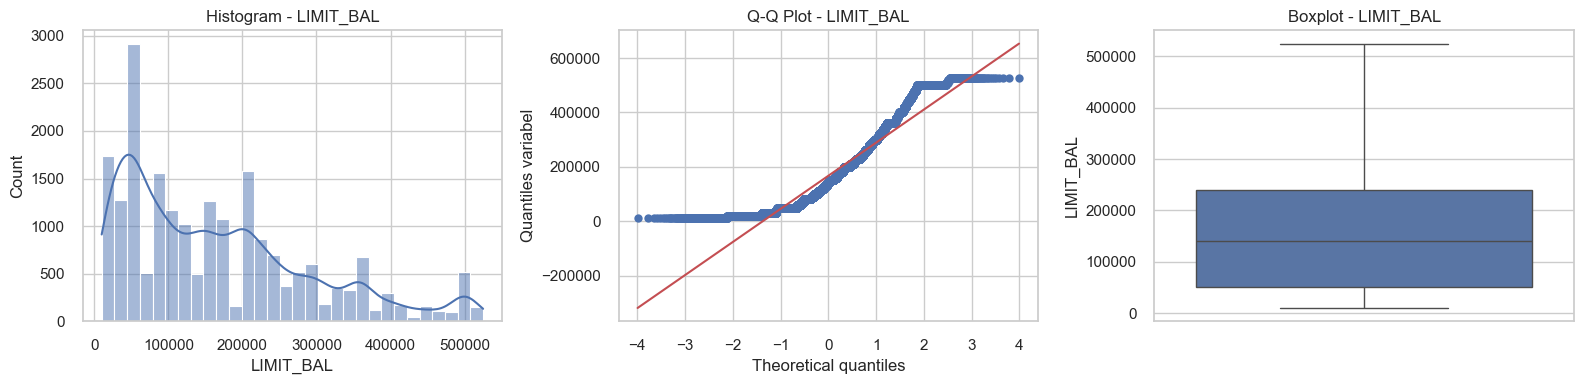

AGE sebelum IQR Capping:


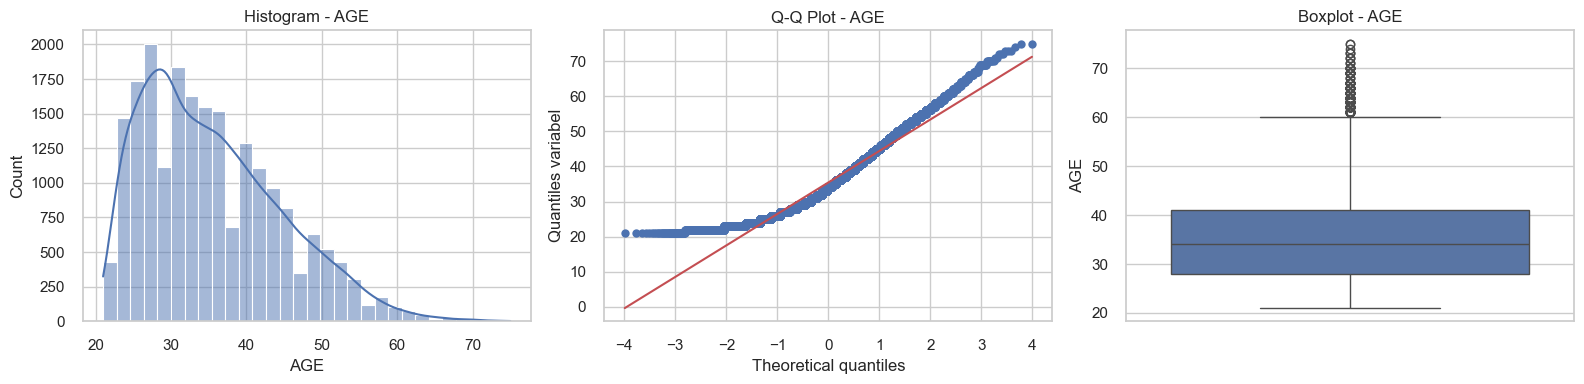

AGE sesudah IQR Capping:


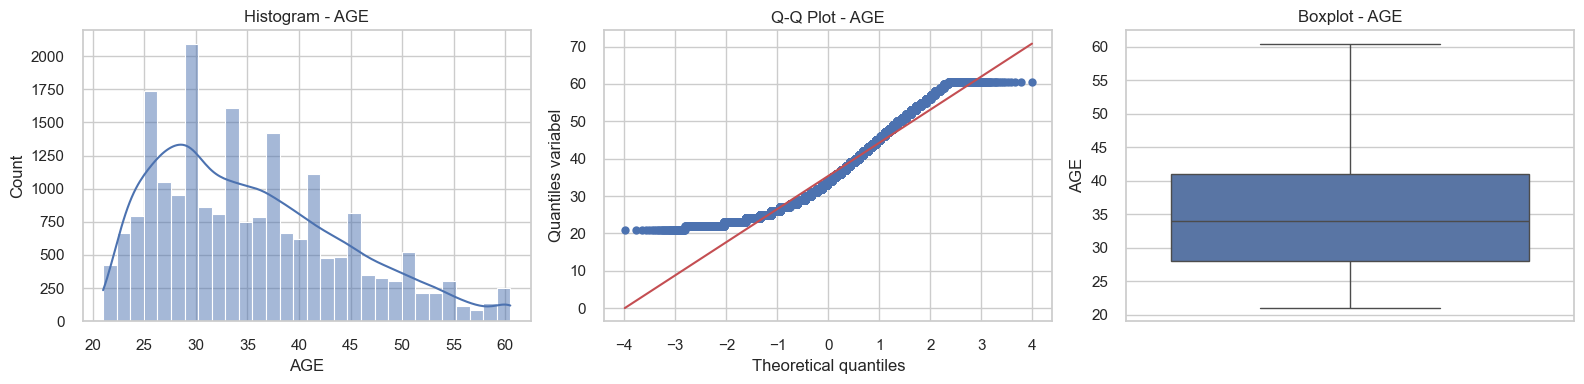

BILL_AMT1 sebelum IQR Capping:


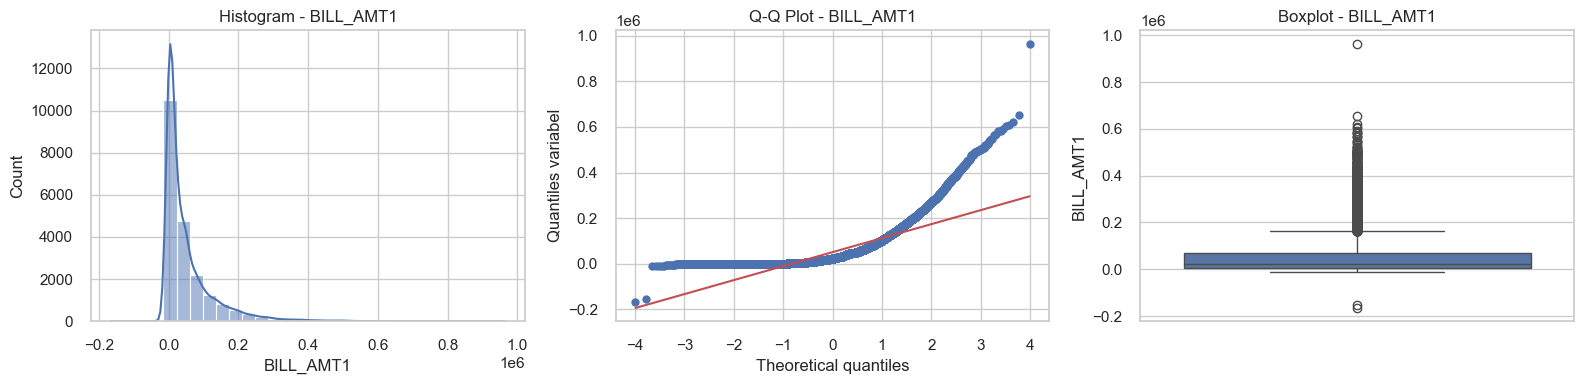

BILL_AMT1 sesudah IQR Capping:


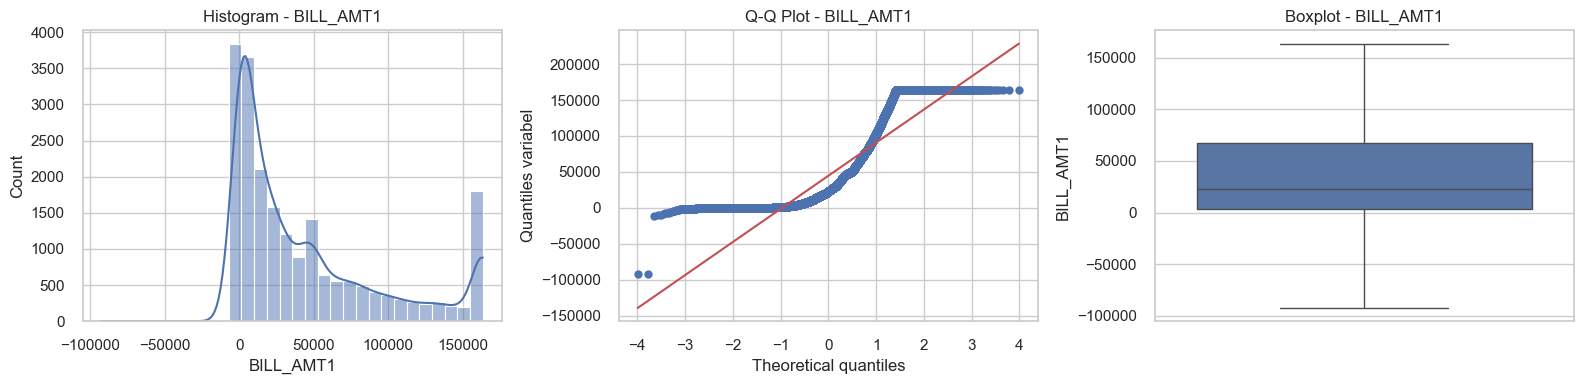

BILL_AMT2 sebelum IQR Capping:


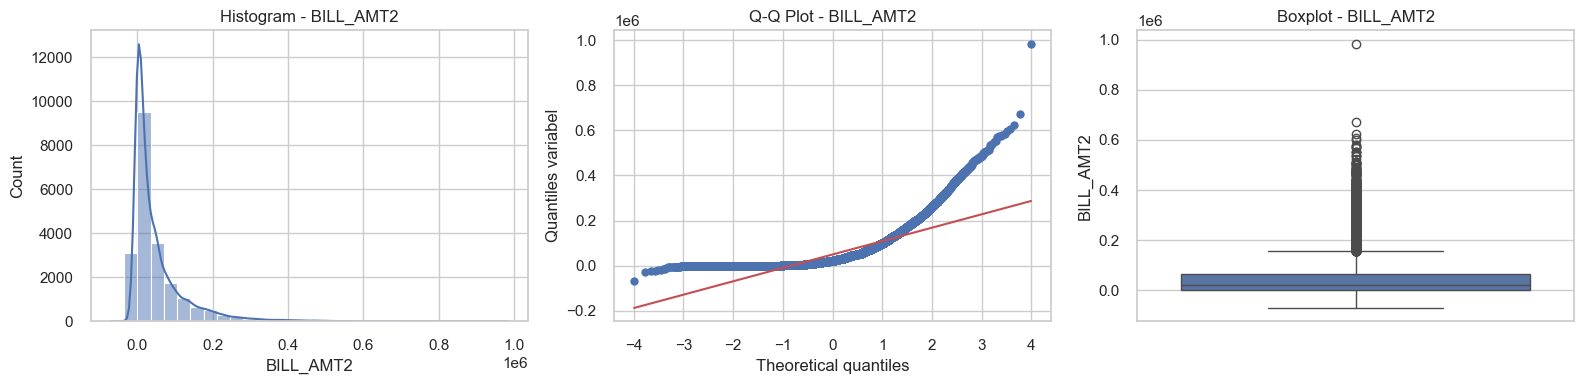

BILL_AMT2 sesudah IQR Capping:


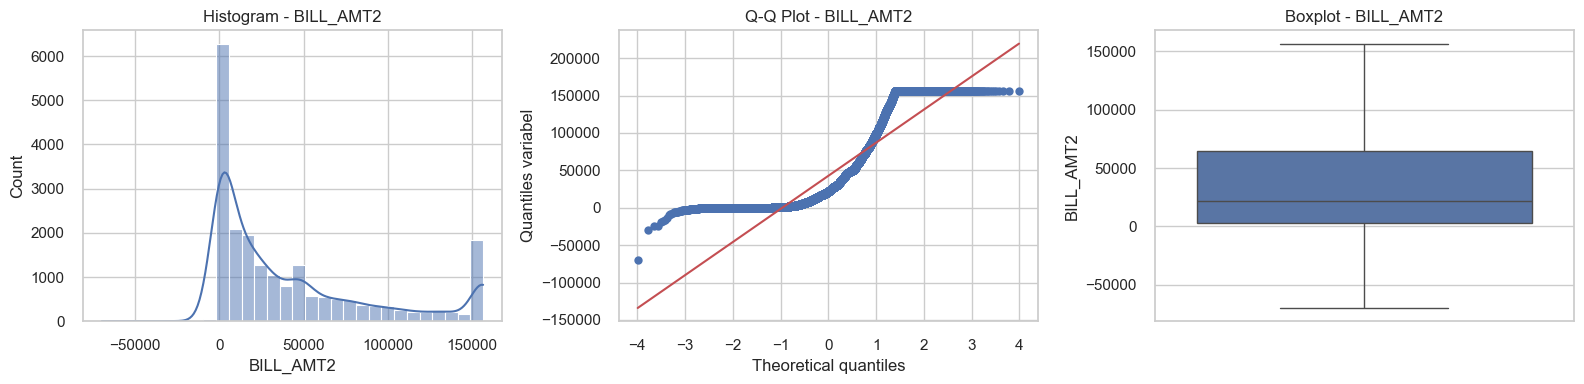

BILL_AMT3 sebelum IQR Capping:


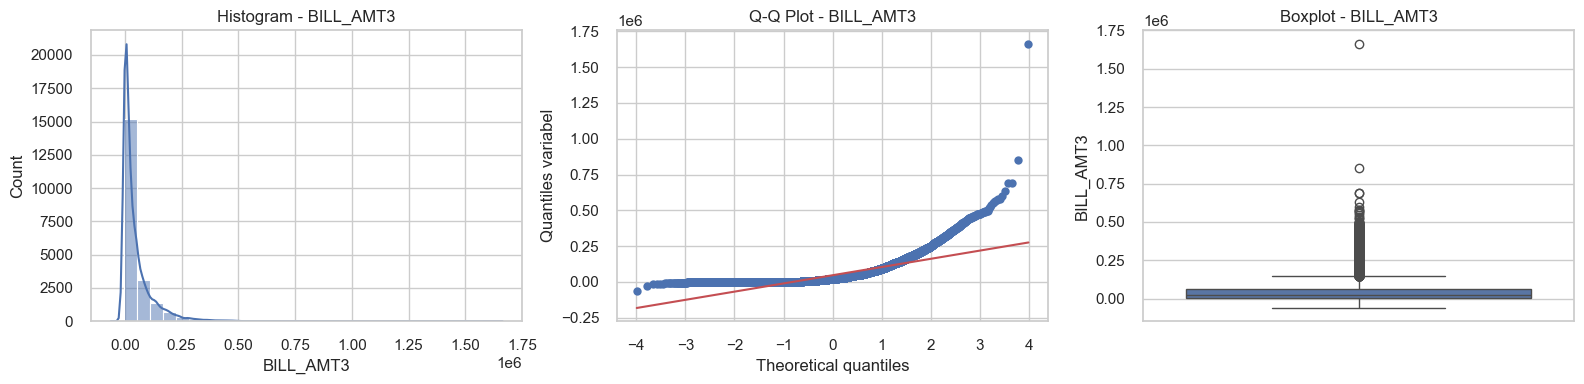

BILL_AMT3 sesudah IQR Capping:


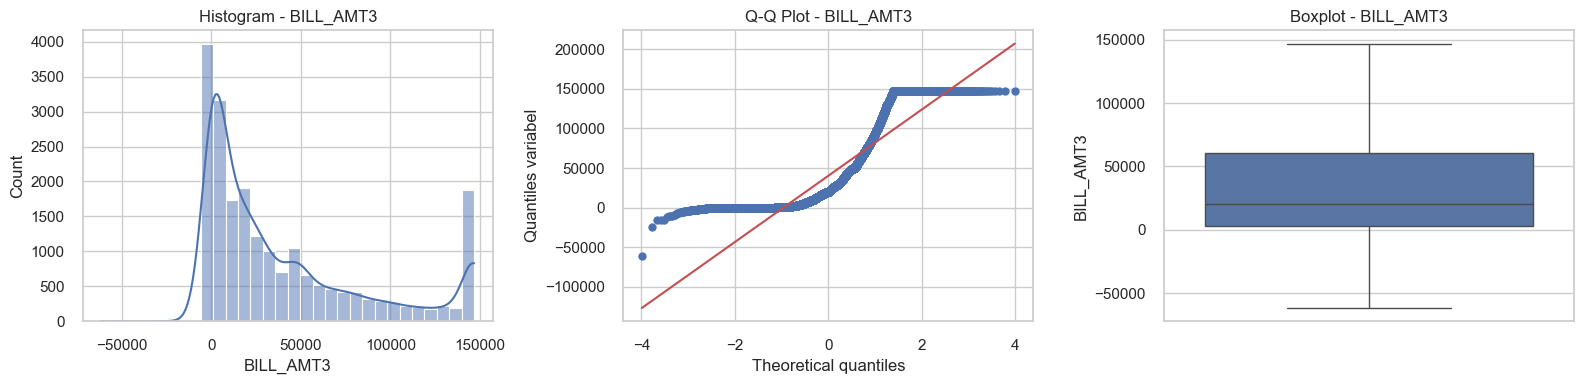

BILL_AMT4 sebelum IQR Capping:


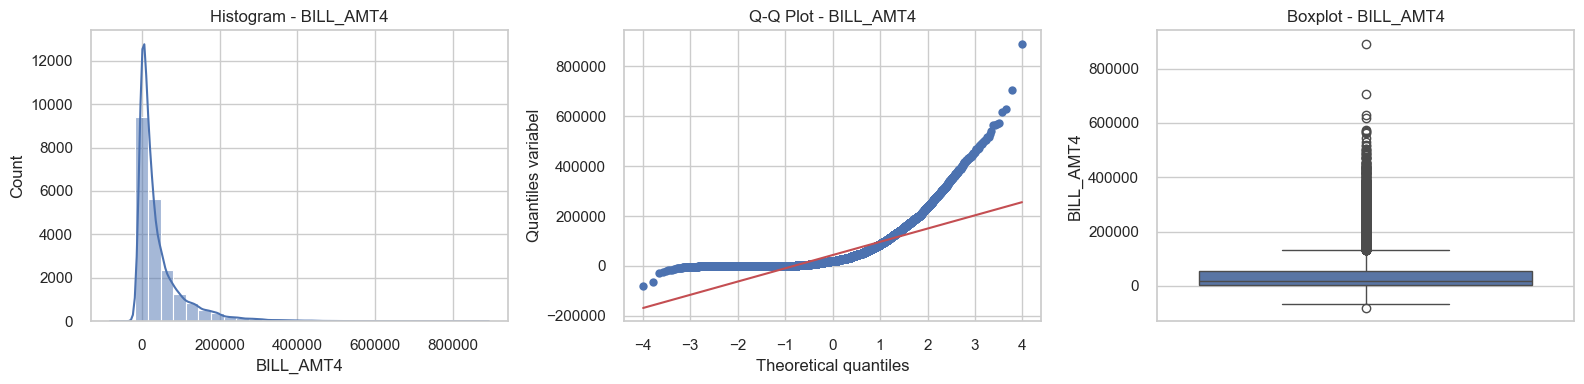

BILL_AMT4 sesudah IQR Capping:


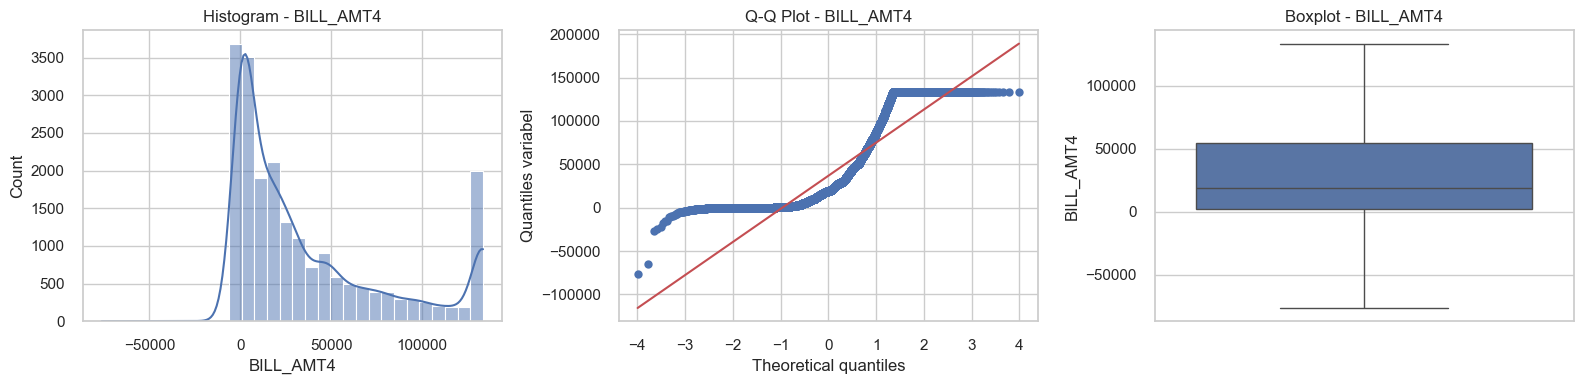

BILL_AMT5 sebelum IQR Capping:


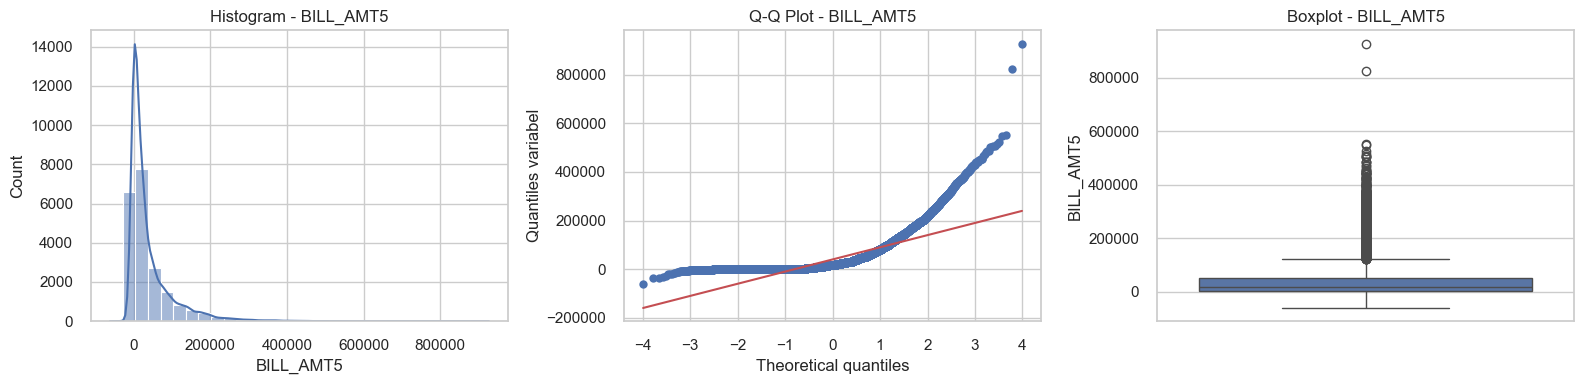

BILL_AMT5 sesudah IQR Capping:


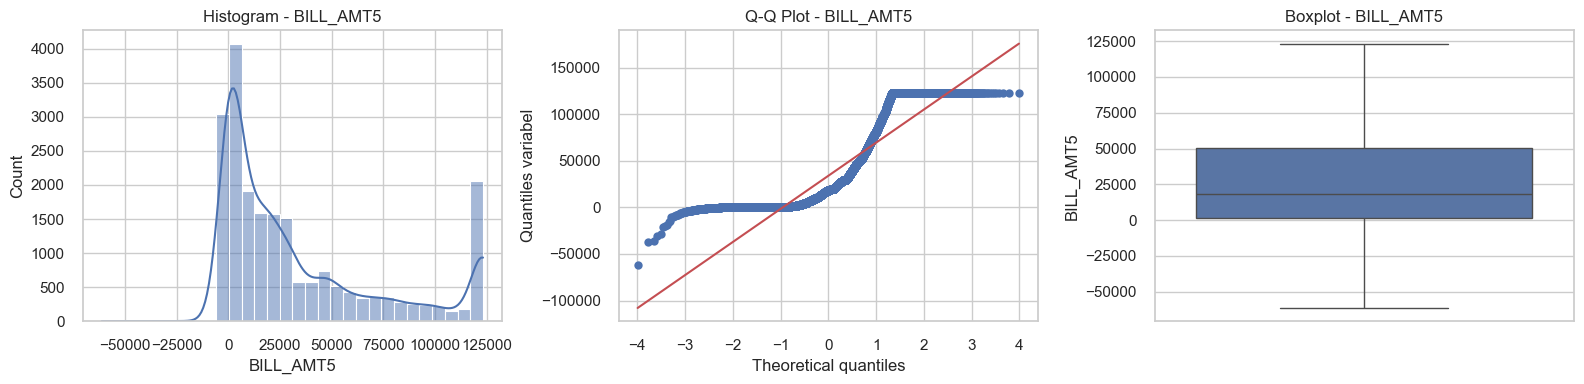

BILL_AMT6 sebelum IQR Capping:


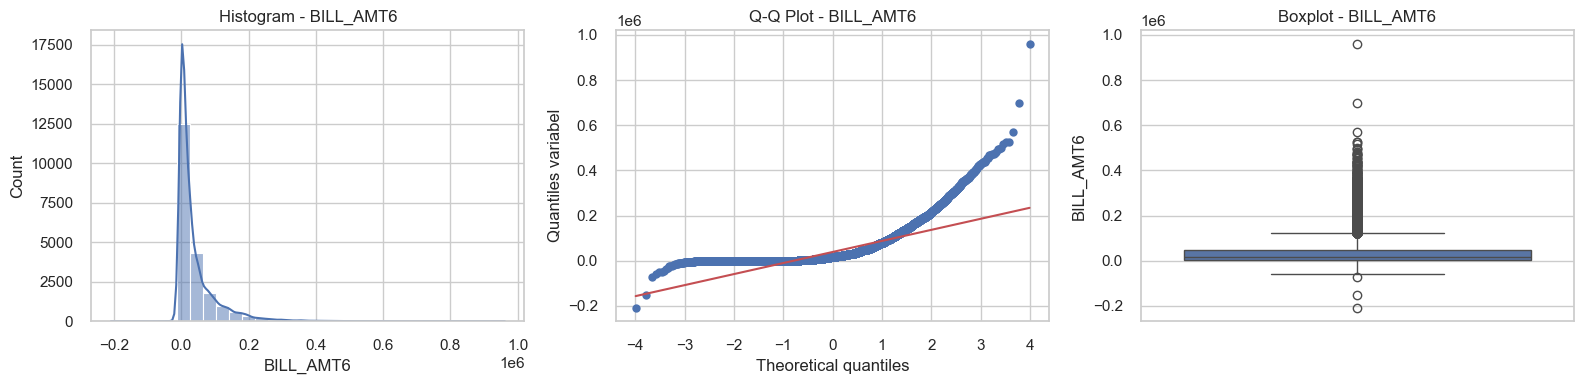

BILL_AMT6 sesudah IQR Capping:


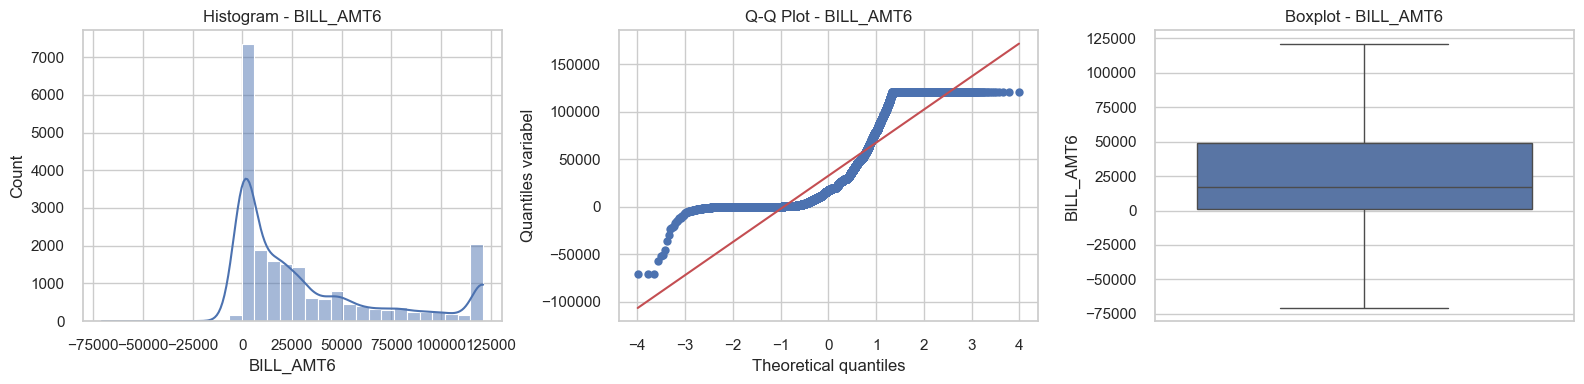

PAY_AMT1 sebelum IQR Capping:


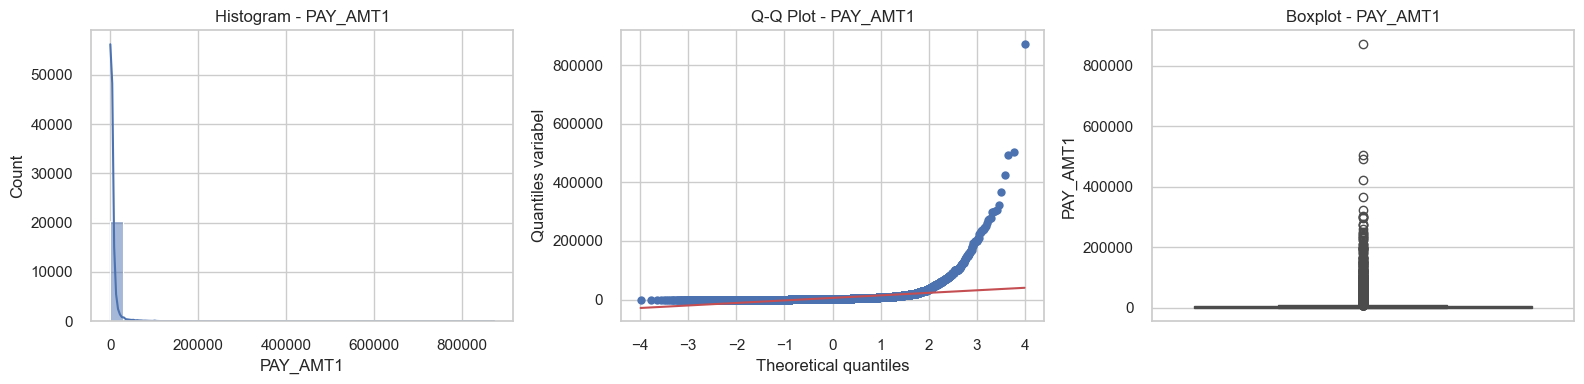

PAY_AMT1 sesudah IQR Capping:


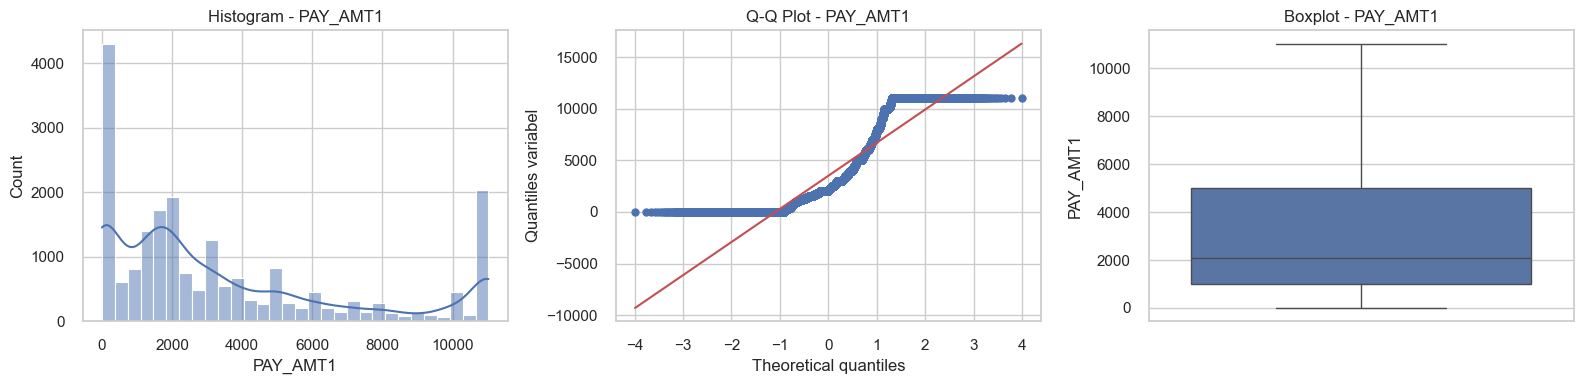

PAY_AMT2 sebelum IQR Capping:


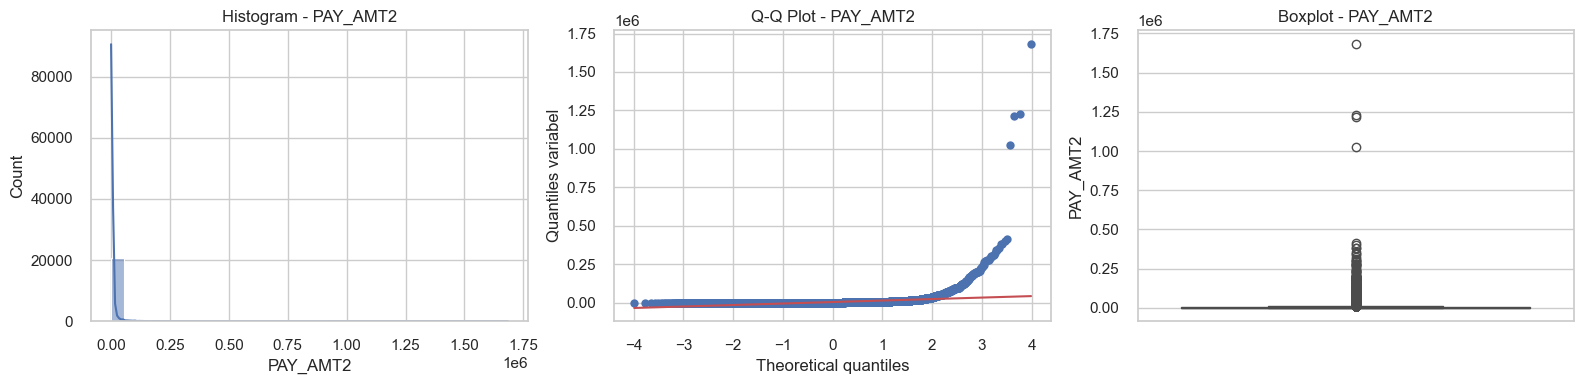

PAY_AMT2 sesudah IQR Capping:


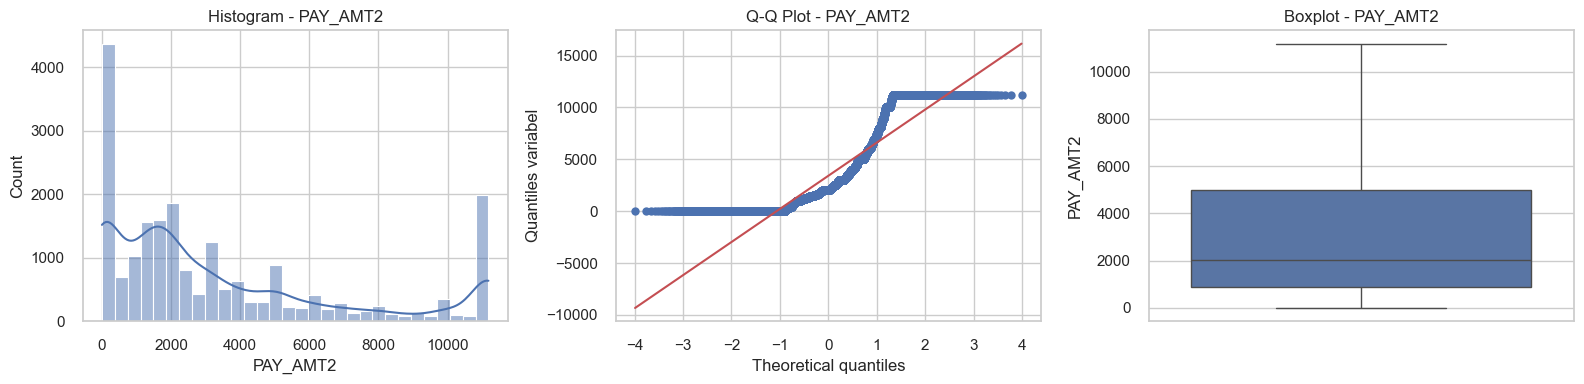

PAY_AMT3 sebelum IQR Capping:


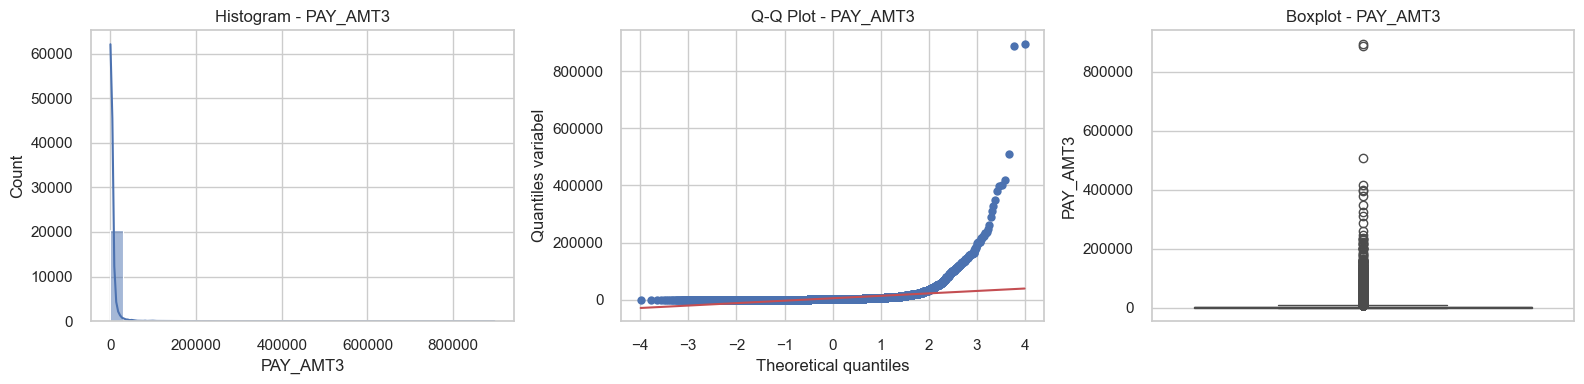

PAY_AMT3 sesudah IQR Capping:


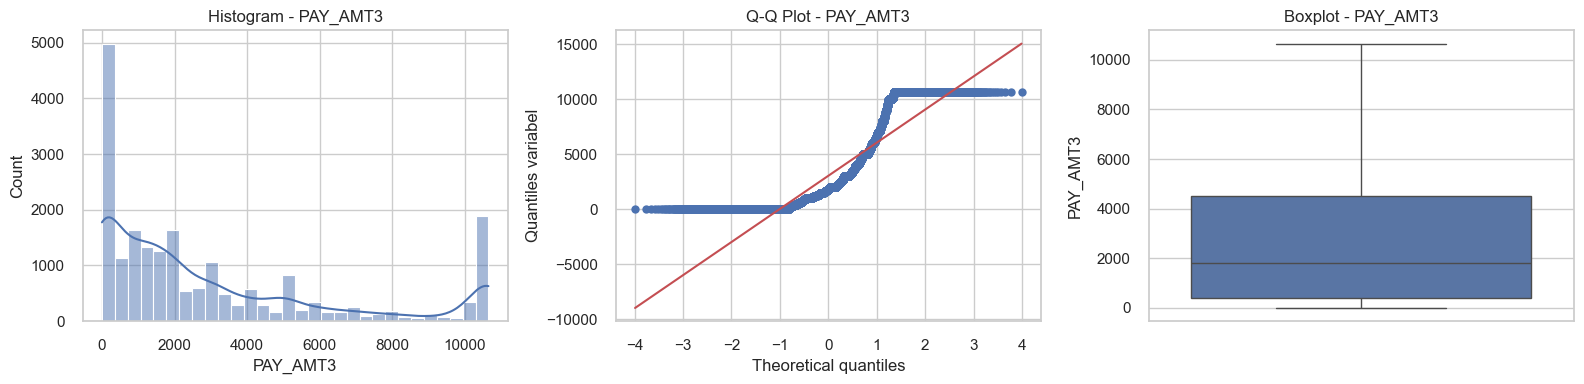

PAY_AMT4 sebelum IQR Capping:


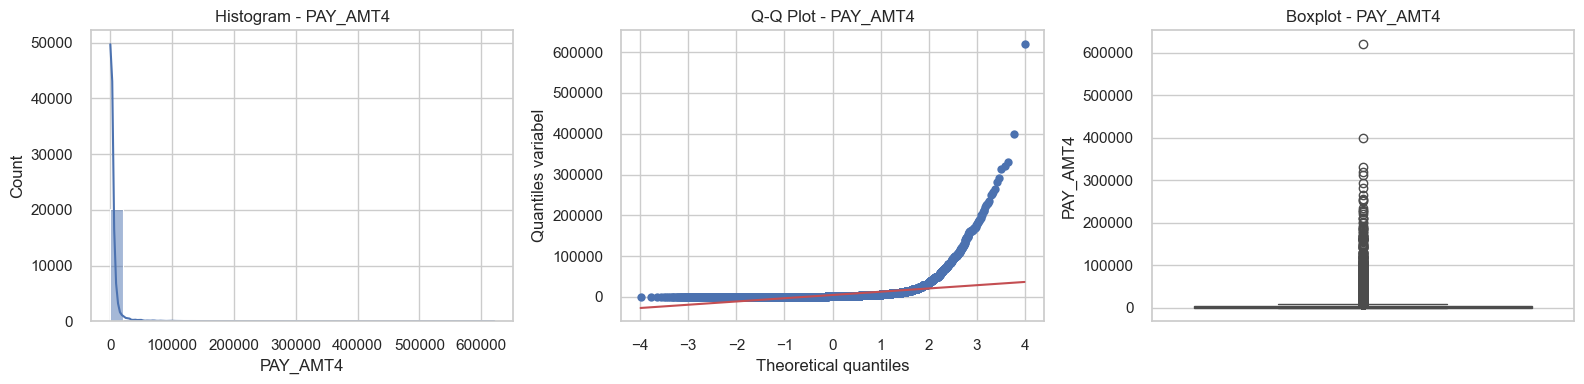

PAY_AMT4 sesudah IQR Capping:


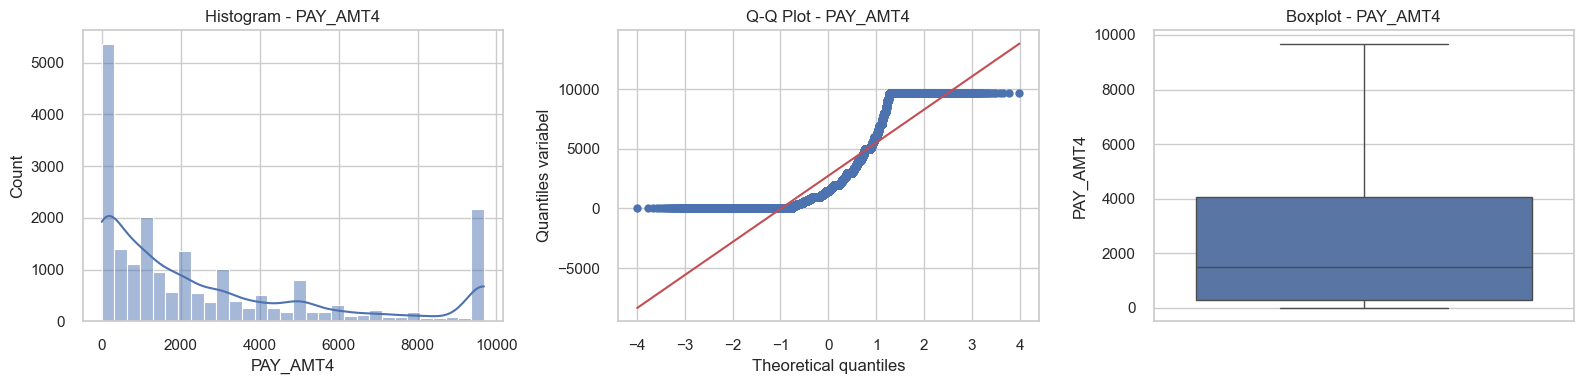

PAY_AMT5 sebelum IQR Capping:


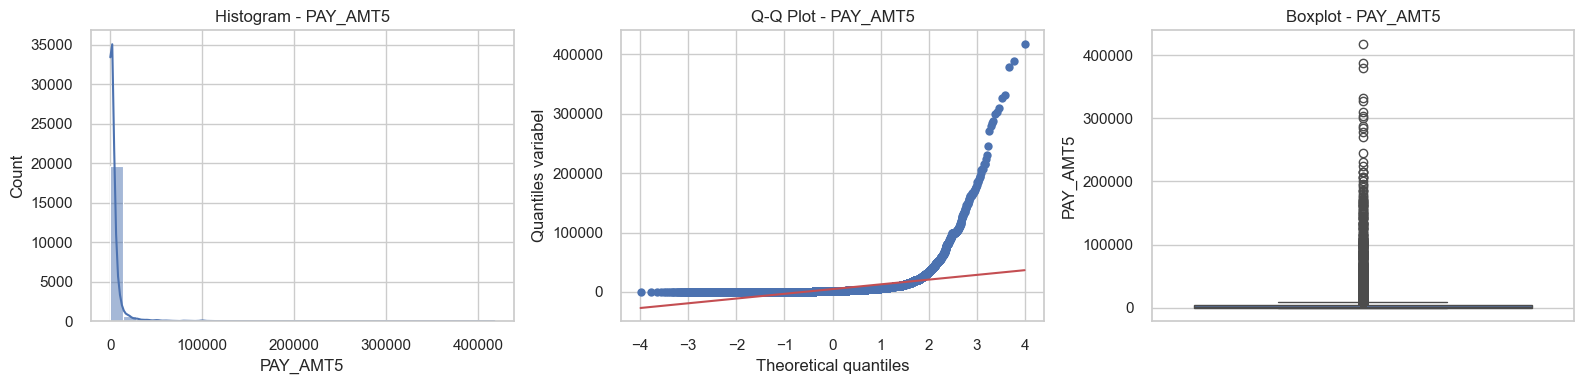

PAY_AMT5 sesudah IQR Capping:


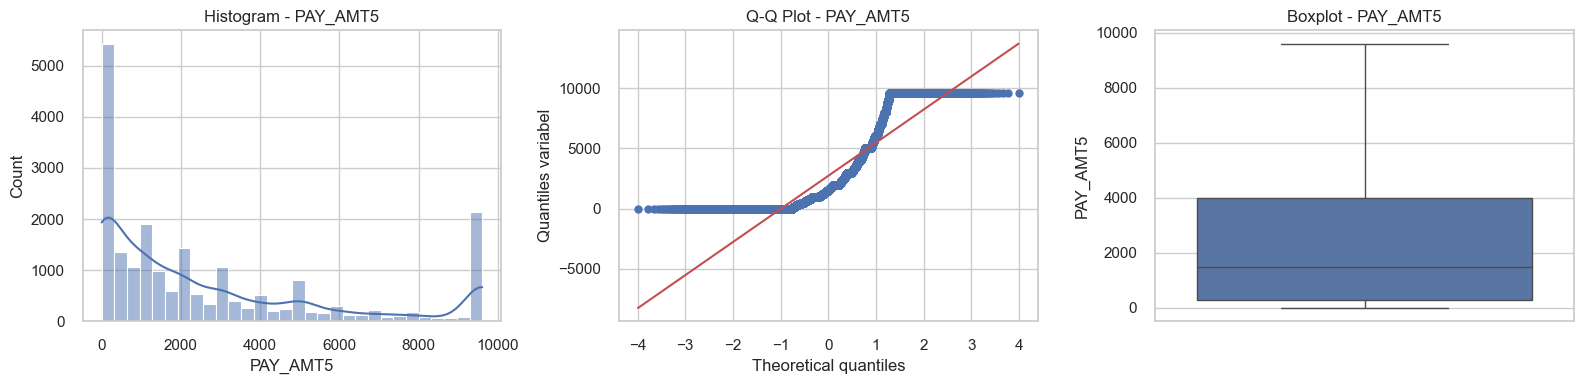

PAY_AMT6 sebelum IQR Capping:


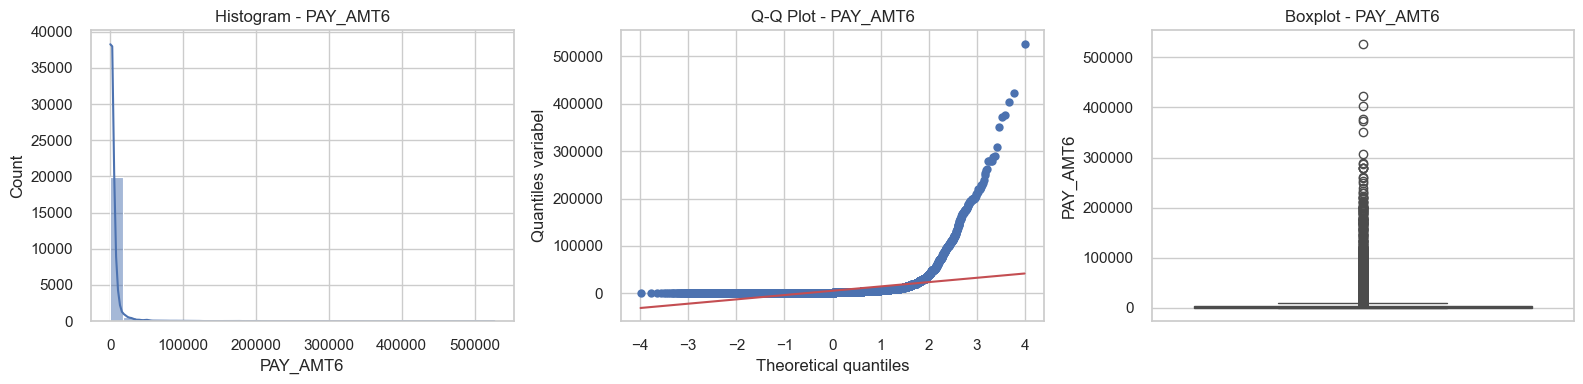

PAY_AMT6 sesudah IQR Capping:


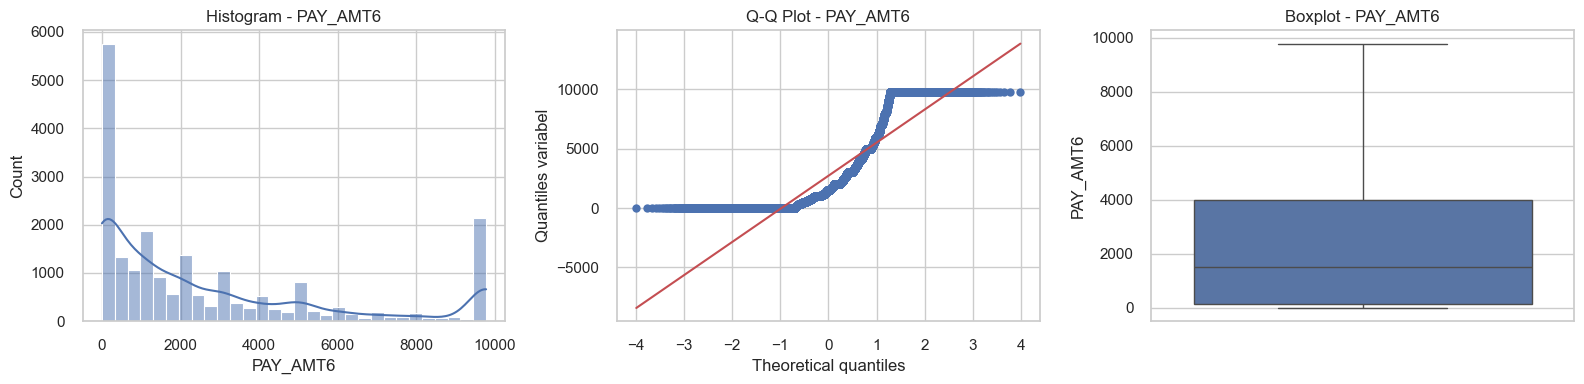

In [11]:
for i in continuous_features:
    print(f"{i} sebelum IQR Capping:")
    check_plot(X_train, i)
    print(f"{i} sesudah IQR Capping:")            
    check_plot(X_train_processed, i)  

## Step 7 — Feature Extraction

**Mengapa (dari EDA 3.7 & 3.8):** enam bulan `BILL_AMT`/`PAY_AMT`/`PAY` saling berkorelasi (*repeated measures* Apr–Sep 2005). Kita ringkas menjadi fitur yang lebih bermakna secara domain risiko kredit:

| Fitur | Makna | Dasar |
|---|---|---|
| `AVG_UTIL_RATIO` | rata-rata utilisasi (tagihan ÷ plafon) | utilisasi tinggi → tekanan kredit |
| `AVG_PAY_AMT` | rata-rata pembayaran 6 bln | kapasitas bayar |
| `N_LATE_PAYMENTS` | jumlah bulan telat (PAY>0) | EDA 3.8: telat ↔ default |
| `MAX_DELAY` | keterlambatan terparah | sinyal risiko terkuat |
| `BILL_TREND` | tagihan bln-1 − bln-6 | arah tren utang |
| `PAY_AMT_STD` | variabilitas pembayaran | ketidakstabilan arus kas |

Catatan: pembagi diberi `+1` untuk menghindari pembagian nol.

In [12]:
def create_features(df_in):
    df = df_in.copy()
    bill_cols   = [f'BILL_AMT{i}' for i in range(1, 7)]
    payamt_cols = [f'PAY_AMT{i}'  for i in range(1, 7)]
    delay_cols  = [f'PAY_{i}'     for i in range(1, 7)]

    df['AVG_UTIL_RATIO']    = df[bill_cols].div(df['LIMIT_BAL'] + 1, axis=0).mean(axis=1)
    df['AVG_PAY_AMT']       = df[payamt_cols].mean(axis=1)
    df['N_LATE_PAYMENTS']   = (df[delay_cols] > 0).sum(axis=1)
    df['MAX_DELAY']         = df[delay_cols].max(axis=1)
    df['BILL_TREND']        = df['BILL_AMT1'] - df['BILL_AMT6']
    df['PAY_AMT_STD']       = df[payamt_cols].std(axis=1).fillna(0)
    return df

X_train_processed = create_features(X_train_processed)
X_test_processed  = create_features(X_test_processed)

new_features = ['AVG_UTIL_RATIO','AVG_PAY_AMT','N_LATE_PAYMENTS','MAX_DELAY',
                'BILL_TREND','PAY_AMT_STD']
X_train_processed[new_features].head()

,AVG_UTIL_RATIO,AVG_PAY_AMT,N_LATE_PAYMENTS,MAX_DELAY,BILL_TREND,PAY_AMT_STD
29863,0.635220,3069.166667,0,0,-8622.00,317.968814
13416,1.773730,4768.625000,2,2,-1533.25,3533.665907
17913,0.104990,0.000000,6,3,0.00,0.000000
28888,0.007279,3988.625000,0,0,105216.75,4998.051655
23485,0.591753,2533.333333,6,2,-3947.00,2201.514630


## Step 8 — Encoding Variabel Kategorik

**Mengapa:** algoritma butuh input numerik, dan kategori **nominal** tidak boleh diberi urutan palsu.
- **`MARRIAGE` (nominal)** → **One-Hot Encoding** (tidak ada hierarki antar status).
- **`SEX` (biner)** → **Label Encoding** (cukup 0/1).
- **`EDUCATION`** dibiarkan sebagai kode integer 1–4 (mendekati ordinal). *Mean encoding* hanya **ditampilkan sebagai analisis** (8.3), tidak diterapkan, untuk menghindari risiko *target leakage*.

### 8.1 One-Hot Encoding — `MARRIAGE`

In [13]:
X_train_processed = pd.get_dummies(X_train_processed, columns=['MARRIAGE'])
X_test_processed  = pd.get_dummies(X_test_processed,  columns=['MARRIAGE'])

# samakan kolom TEST dengan TRAIN (kategori yg mungkin tak muncul di TEST -> 0)
for col in X_train_processed.columns:
    if col not in X_test_processed.columns:
        X_test_processed[col] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

marriage_ohe = [c for c in X_train_processed.columns if c.startswith('MARRIAGE_')]
X_train_processed[marriage_ohe] = X_train_processed[marriage_ohe].astype(int)
X_test_processed[marriage_ohe]  = X_test_processed[marriage_ohe].astype(int)
print('Kolom hasil OHE:', marriage_ohe)

Kolom hasil OHE: ['MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


### 8.2 Label Encoding — `SEX`

In [14]:
label_encoder = LabelEncoder()
X_train_processed['SEX'] = label_encoder.fit_transform(X_train_processed['SEX'])
X_test_processed['SEX']  = label_encoder.transform(X_test_processed['SEX'])
print('Mapping SEX:', dict(zip(label_encoder.classes_,
                                label_encoder.transform(label_encoder.classes_))))

Mapping SEX: {1: 0, 2: 1}


## Step 10 — Feature Selection

**Mengapa (dari EDA 3.7):** banyak fitur redundan/berkorelasi → multikolinearitas & risiko *overfit*. Strategi yang **benar-benar mengubah** dataset: (10.2) buang pasangan berkorelasi > 0,85, dan (10.3) buang fitur tidak signifikan (ANOVA p > 0,05). Metode lain (RFE, LASSO, RF importance) ditampilkan sebagai **konfirmasi/perbandingan** — semua di-*fit* dari TRAIN.

### 10.1 Filter — Korelasi Pearson terhadap target

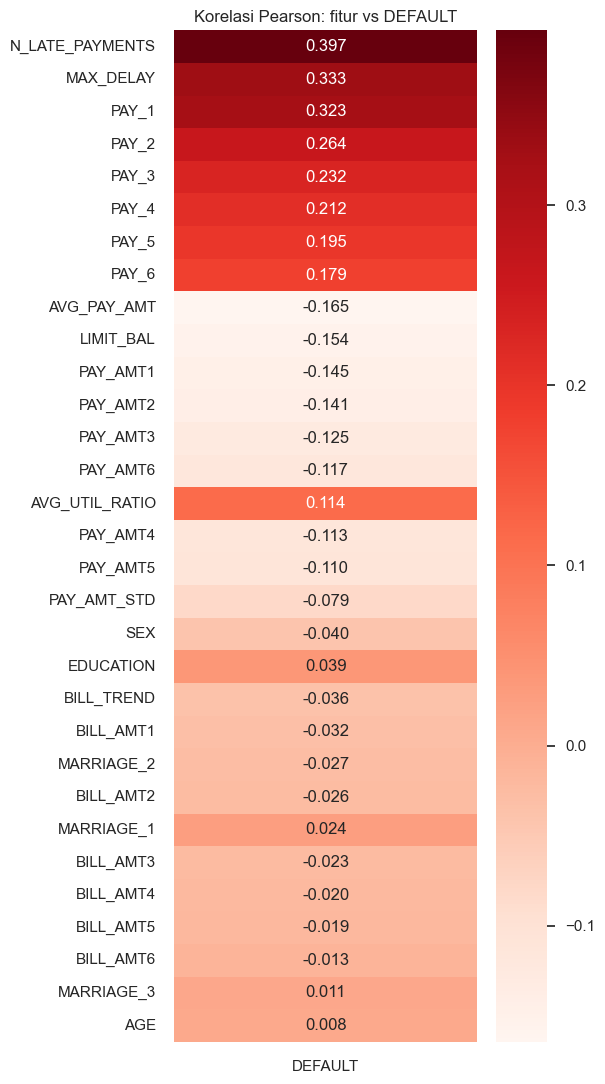

Fitur dengan |r| > 0.1:
                 DEFAULT
N_LATE_PAYMENTS    0.397
MAX_DELAY          0.333
PAY_1              0.323
PAY_2              0.264
PAY_3              0.232
PAY_4              0.212
PAY_5              0.195
PAY_6              0.179
AVG_PAY_AMT       -0.165
LIMIT_BAL         -0.154
PAY_AMT1          -0.145
PAY_AMT2          -0.141
PAY_AMT3          -0.125
PAY_AMT6          -0.117
AVG_UTIL_RATIO     0.114
PAY_AMT4          -0.113
PAY_AMT5          -0.110


In [15]:
df_corr = X_train_processed.copy()
df_corr['DEFAULT'] = y_train.values
target_corr = df_corr.corr()[['DEFAULT']].drop('DEFAULT')

plt.figure(figsize=(6, 11))
sns.heatmap(target_corr.sort_values('DEFAULT', key=abs, ascending=False),
            annot=True, cmap='Reds', fmt='.3f')
plt.title("Korelasi Pearson: fitur vs DEFAULT")
plt.tight_layout(); plt.show()

relevant = target_corr[abs(target_corr['DEFAULT']) > 0.1]
print('Fitur dengan |r| > 0.1:')
print(relevant.sort_values('DEFAULT', key=abs, ascending=False).round(3))

### 10.2 Multikolinearitas — buang fitur berkorelasi > 0,85

In [16]:
corr_matrix = X_train_processed.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
to_drop = set()
for col in upper_tri.columns:
    for row in upper_tri.index[upper_tri[col] > threshold]:
        # dari pasangan berkorelasi, buang yg lebih lemah korelasinya ke target
        c1 = abs(X_train_processed[col].corr(y_train))
        c2 = abs(X_train_processed[row].corr(y_train))
        weaker = col if c1 < c2 else row
        to_drop.add(weaker)
        print(f'  {col} <-> {row}: {corr_matrix.loc[col, row]:.3f}  -> buang {weaker}')

if to_drop:
    X_train_processed.drop(columns=list(to_drop), inplace=True)
    X_test_processed.drop(columns=list(to_drop), inplace=True)
    print(f'\n{len(to_drop)} fitur redundan dibuang: {sorted(to_drop)}')
else:
    print('Tidak ada pasangan > 0.85')

  BILL_AMT2 <-> BILL_AMT1: 0.948  -> buang BILL_AMT2
  BILL_AMT3 <-> BILL_AMT1: 0.900  -> buang BILL_AMT3
  BILL_AMT3 <-> BILL_AMT2: 0.939  -> buang BILL_AMT3
  BILL_AMT4 <-> BILL_AMT1: 0.852  -> buang BILL_AMT4
  BILL_AMT4 <-> BILL_AMT2: 0.886  -> buang BILL_AMT4
  BILL_AMT4 <-> BILL_AMT3: 0.932  -> buang BILL_AMT4
  BILL_AMT5 <-> BILL_AMT3: 0.883  -> buang BILL_AMT5
  BILL_AMT5 <-> BILL_AMT4: 0.933  -> buang BILL_AMT5
  BILL_AMT6 <-> BILL_AMT4: 0.892  -> buang BILL_AMT6
  BILL_AMT6 <-> BILL_AMT5: 0.939  -> buang BILL_AMT6
  MARRIAGE_2 <-> MARRIAGE_1: 0.979  -> buang MARRIAGE_1

6 fitur redundan dibuang: ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'MARRIAGE_1']


### 10.3 Filter — ANOVA F-test (buang p > 0,05)

In [17]:
fs = SelectKBest(score_func=f_classif, k='all').fit(X_train_processed, y_train)
anova = pd.DataFrame({'Feature': X_train_processed.columns,
                      'F': fs.scores_, 'p': fs.pvalues_}).sort_values('F', ascending=False)
print('Top 15 ANOVA F-score:'); print(anova.head(15).round(3).to_string(index=False))

insignif = anova[anova['p'] > 0.05]['Feature'].tolist()
if insignif:
    X_train_processed.drop(columns=insignif, inplace=True)
    X_test_processed.drop(columns=insignif, inplace=True)
    print(f'\nDibuang (p>0.05): {insignif}')
else:
    print('\nSemua fitur signifikan (p<=0.05)')
print('Fitur terpilih:')
for i in X_train_processed.columns :
    print(f'- {i}')
print('Dimensi sekarang:', X_train_processed.shape)

Top 15 ANOVA F-score:
        Feature        F   p
N_LATE_PAYMENTS 3924.664 0.0
      MAX_DELAY 2606.999 0.0
          PAY_1 2448.008 0.0
          PAY_2 1570.530 0.0
          PAY_3 1191.745 0.0
          PAY_4  990.658 0.0
          PAY_5  831.151 0.0
          PAY_6  697.453 0.0
    AVG_PAY_AMT  583.347 0.0
      LIMIT_BAL  510.052 0.0
       PAY_AMT1  451.395 0.0
       PAY_AMT2  428.081 0.0
       PAY_AMT3  334.179 0.0
       PAY_AMT6  292.353 0.0
 AVG_UTIL_RATIO  277.102 0.0

Dibuang (p>0.05): ['MARRIAGE_3', 'AGE']
Fitur terpilih:
- LIMIT_BAL
- SEX
- EDUCATION
- PAY_1
- PAY_2
- PAY_3
- PAY_4
- PAY_5
- PAY_6
- BILL_AMT1
- PAY_AMT1
- PAY_AMT2
- PAY_AMT3
- PAY_AMT4
- PAY_AMT5
- PAY_AMT6
- AVG_UTIL_RATIO
- AVG_PAY_AMT
- N_LATE_PAYMENTS
- MAX_DELAY
- BILL_TREND
- PAY_AMT_STD
- MARRIAGE_2
Dimensi sekarang: (20975, 23)


In [18]:
X_train_processed.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_AMT', 'N_LATE_PAYMENTS',
       'MAX_DELAY', 'BILL_TREND', 'PAY_AMT_STD', 'MARRIAGE_2'],
      dtype='object')

## Step 11 — Feature Scaling (StandardScaler / Z-Score)

**Mengapa (dari EDA 3.2):** skala antar fitur sangat berbeda (NT$ ratusan ribu vs umur puluhan vs status satuan). Banyak algoritma sensitif terhadap skala. **StandardScaler** dipilih (cocok untuk data berekor yang sudah di-cap). Kolom **biner/ordinal/OHE tidak di-scale** karena sudah 0/1 atau berskala kecil bermakna. Scaler **di-*fit* pada TRAIN**, lalu `transform` ke TEST.

In [19]:
binary_and_ordinal = ['SEX', 'EDUCATION', 'AGE_GROUP'] + [c for c in X_train_processed.columns if c.startswith('MARRIAGE_')]
columns_to_stdscaler = [c for c in X_train_processed.columns if c not in binary_and_ordinal]

print(f'Di-scale ({len(columns_to_stdscaler)}): {columns_to_stdscaler}')

X_train_before_scaling = X_train_processed.copy()
scaler = StandardScaler()
X_train_processed[columns_to_stdscaler] = scaler.fit_transform(X_train_processed[columns_to_stdscaler])
X_test_processed[columns_to_stdscaler]  = scaler.transform(X_test_processed[columns_to_stdscaler])

print('\nVerifikasi (mean~0, std~1):')
print(X_train_processed[columns_to_stdscaler[:5]].describe().loc[['mean', 'std']].round(3))

Di-scale (20): ['LIMIT_BAL', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_AMT', 'N_LATE_PAYMENTS', 'MAX_DELAY', 'BILL_TREND', 'PAY_AMT_STD']

Verifikasi (mean~0, std~1):
      LIMIT_BAL  PAY_1  PAY_2  PAY_3  PAY_4
mean        0.0   -0.0    0.0   -0.0   -0.0
std         1.0    1.0    1.0    1.0    1.0


---
# MODELING

In [ ]:
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
spw = (y_train == 0).sum() / (y_train == 1).sum() 

# Target generalisasi: gap ROC-AUC rata-rata Train-Test pada learning curve harus < 10%
GAP_TARGET = 0.10

results = {} 

def learning_curve_train_test_auc(factory, X_train, y_train, X_test, y_test,
                                  train_sizes=np.linspace(0.2, 1.0, 6),
                                  repeats=4, random_state=42, title=None):
    n_total = len(X_train)
    sizes, tr_m, tr_s, te_m, te_s = [], [], [], [], []
    for frac in train_sizes:
        n_sub = min(int(np.ceil(frac * n_total)), n_total)
        tr_scores, te_scores = [], []
        if n_sub >= n_total:
            subsets = [np.arange(n_total)]
        else:
            sss = StratifiedShuffleSplit(n_splits=repeats, train_size=n_sub, random_state=random_state)
            subsets = [idx for idx, _ in sss.split(X_train, y_train)]
        for idx in subsets:
            Xs, ys = X_train.iloc[idx], y_train.iloc[idx]
            clf = factory().fit(Xs, ys)
            tr_scores.append(roc_auc_score(ys, clf.predict_proba(Xs)[:, 1]))
            te_scores.append(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
        sizes.append(n_sub)
        tr_m.append(np.mean(tr_scores)); tr_s.append(np.std(tr_scores))
        te_m.append(np.mean(te_scores)); te_s.append(np.std(te_scores))
    sizes = np.array(sizes)
    tr_m, tr_s = np.array(tr_m), np.array(tr_s)
    te_m, te_s = np.array(te_m), np.array(te_s)

    # Gap ROC-AUC Train-Test: pada titik akhir (data penuh) dan rata-rata sepanjang kurva
    final_gap = float(tr_m[-1] - te_m[-1])
    mean_gap  = float(np.mean(tr_m - te_m))
    status = 'OK (< target)' if mean_gap < GAP_TARGET else 'DI ATAS TARGET'

    plt.figure(figsize=(7, 5))
    plt.plot(sizes, tr_m, marker='o', label='Train ROC-AUC')
    plt.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    plt.plot(sizes, te_m, marker='s', label='Test ROC-AUC')
    plt.fill_between(sizes, te_m - te_s, te_m + te_s, alpha=0.15)
    plt.ylim(0.5, 1.0); plt.grid(alpha=0.25); plt.legend()
    plt.xlabel('Number of Training Samples'); plt.ylabel('ROC-AUC')
    base_title = title or 'Learning Curve ROC-AUC (Train vs Test)'
    plt.title(f'{base_title}\nGap rata-rata={mean_gap*100:.2f}% | akhir={final_gap*100:.2f}% '
              f'(target < {GAP_TARGET*100:.0f}%) -> {status}')
    plt.tight_layout(); plt.show()

    print(f'[Learning Curve] {base_title} | gap rata-rata={mean_gap*100:.2f}% '
          f'| gap akhir={final_gap*100:.2f}% | target < {GAP_TARGET*100:.0f}% -> {status}')
    return {'sizes': sizes, 'train_auc': tr_m, 'test_auc': te_m,
            'final_gap': final_gap, 'mean_gap': mean_gap}

def evaluate_model_main(name, model, store=True, plot=True, lc=False, factory=None):
    cv_auc = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    model.fit(X_train_processed, y_train)
    proba_tr = model.predict_proba(X_train_processed)[:, 1]
    proba_te = model.predict_proba(X_test_processed)[:, 1]
    pred_tr  = model.predict(X_train_processed)
    pred_te  = model.predict(X_test_processed)
    auc_tr = roc_auc_score(y_train, proba_tr)
    auc_te = roc_auc_score(y_test, proba_te)
    rec_tr = recall_score(y_train, pred_tr)
    rec_te = recall_score(y_test, pred_te)
    gap_tt, gap_ct = auc_tr - auc_te, cv_auc - auc_te
    gap_recall = rec_tr - rec_te
    print(f'\n=== {name} ===')
    print(f'  AUC Train : {auc_tr:.4f}')
    print(f'  AUC CV    : {cv_auc:.4f}')
    print(f'  AUC Test  : {auc_te:.4f}')
    print(f'  Gap Train-Test : {gap_tt:.4f}')
    print(f'  Gap CV-Test    : {gap_ct:.4f}')
    print(f'  Recall Train      : {rec_tr:.4f}')
    print(f'  Recall Test       : {rec_te:.4f}')
    print(f'  Gap Recall (Tr-Te): {gap_recall:.4f}')
    if plot:
        y_pred = pred_te
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, ax=ax[0])
        ax[0].set_title(f'{name} - Confusion Matrix (Test)')
        fpr, tpr, _ = roc_curve(y_test, proba_te)
        fpr2, tpr2, _ = roc_curve(y_train, proba_tr)
        ax[1].plot(fpr, tpr, label=f'Test AUC={auc_te:.3f}')
        ax[1].plot(fpr2, tpr2, ls='--', alpha=0.6, label=f'Train AUC={auc_tr:.3f}')
        ax[1].plot([0, 1], [0, 1], 'k:', lw=1)
        ax[1].set(xlabel='FPR', ylabel='TPR', title=f'{name} - ROC')
        ax[1].legend(loc='lower right')
        plt.tight_layout(); plt.show()
    lc_info = None
    if lc and factory is not None:
        lc_info = learning_curve_train_test_auc(factory, X_train_processed, y_train,
                                                X_test_processed, y_test, title=name)
    if store:
        results[name] = {'model': model, 'auc_train': auc_tr, 'auc_cv': cv_auc,
                         'auc_test': auc_te, 'gap_tt': gap_tt, 'gap_ct': gap_ct,
                         'recall_train': rec_tr, 'recall_test': rec_te, 'gap_recall': gap_recall,
                         'lc_mean_gap': (lc_info['mean_gap'] if lc_info else None)}
    return model


Kelas *default* adalah minoritas (~22%), sehingga model cenderung bias ke kelas mayoritas dan **recall** kelas default rendah. Di sini beberapa kandidat teknik penyeimbang diuji secara **objektif** lalu yang terbaik dipilih otomatis menjadi `IMB_SAMPLER`.

**Prinsip anti-leakage:** resampling **hanya** dilakukan pada data latih di tiap *fold*. Pada jalur manual (tuning, evaluasi, learning curve) hal ini dijamin dengan membungkus sampler + estimator dalam `imblearn.pipeline.Pipeline` (`ImbPipeline`), sehingga `cross_validate`/`cross_val_score` me-*resample* lipatan latih saja dan **AUC train tetap diukur pada data asli (tidak di-resample)** — penting agar estimasi *gap* jujur. Pada jalur PyCaret, hal setara ditangani oleh `fix_imbalance=True` (per-fold). **Test set tidak pernah di-resample.**

**Kriteria pemilihan** menggabungkan tiga hal: (1) ROC-AUC CV setinggi mungkin, (2) *gap* AUC train-test ditekan di bawah target 10%, dan (3) selisih *recall* train-test sekecil mungkin (recall seimbang). Skornya:

`Skor = AUC_CV − 3.0 · max(0, gap_AUC − 0.10) − 1.0 · |gap_recall|`

> Catatan: untuk evaluasi/finalisasi di PyCaret (Step 15–16) estimator diberikan **tanpa** pembungkus sampler (PyCaret sudah menangani imbalance), agar tidak terjadi *double resampling*. Jalur manual tetap memakai `ImbPipeline`.


In [68]:
# Pemilihan teknik imbalance handling 
def probe_estimator():
    return GradientBoostingClassifier(
        random_state=42, n_estimators=250, learning_rate=0.05, max_depth=3,
        subsample=0.8, min_samples_leaf=60, max_features='sqrt')

candidate_samplers = {
    'SMOTE'             : SMOTE(random_state=42),
    'SMOTE (0.5)'       : SMOTE(random_state=42, sampling_strategy=0.5),
    'BorderlineSMOTE'   : BorderlineSMOTE(random_state=42),
    'ADASYN'            : ADASYN(random_state=42),
    'SMOTETomek'        : SMOTETomek(random_state=42),
    'SMOTEENN'          : SMOTEENN(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
}

PENALTY_AUC = 3.0   # penalti bila gap AUC train-test melebihi target
PENALTY_REC = 1.0   # penalti untuk ketidakseimbangan recall train-test

imb_rows = []
for nm, sampler in candidate_samplers.items():
    pipe = ImbPipeline([('resampler', clone(sampler)), ('clf', probe_estimator())])
    sc = cross_validate(pipe, X_train_processed, y_train, cv=cv,
                        scoring=['roc_auc', 'recall'], return_train_score=True, n_jobs=-1)
    auc_te = sc['test_roc_auc'].mean(); auc_tr = sc['train_roc_auc'].mean()
    rec_te = sc['test_recall'].mean();  rec_tr = sc['train_recall'].mean()
    gap_auc = auc_tr - auc_te
    gap_rec = abs(rec_tr - rec_te)
    score = auc_te - PENALTY_AUC * max(0.0, gap_auc - GAP_TARGET) - PENALTY_REC * gap_rec
    imb_rows.append({'Teknik': nm, 'AUC_CV': round(auc_te, 4), 'Gap_AUC': round(gap_auc, 4),
                     'Recall_CV': round(rec_te, 4), 'Gap_Recall': round(gap_rec, 4),
                     'Skor': round(score, 4)})

imb_leaderboard = pd.DataFrame(imb_rows).sort_values('Skor', ascending=False).reset_index(drop=True)
print(imb_leaderboard.to_string(index=False))

best_imb_name = imb_leaderboard.iloc[0]['Teknik']
IMB_SAMPLER = clone(candidate_samplers[best_imb_name])
print(f'\nTeknik imbalance terpilih: {best_imb_name}  ->  {type(IMB_SAMPLER).__name__}')


            Teknik  AUC_CV  Gap_AUC  Recall_CV  Gap_Recall   Skor
       SMOTE (0.5)  0.7810   0.0223     0.4691      0.0107 0.7704
             SMOTE  0.7727   0.0206     0.6074      0.0154 0.7573
RandomUnderSampler  0.7823   0.0257     0.6535      0.0263 0.7559
          SMOTEENN  0.7775   0.0172     0.7315      0.0230 0.7545
        SMOTETomek  0.7728   0.0206     0.6033      0.0185 0.7543
            ADASYN  0.7665   0.0226     0.6231      0.0205 0.7460
   BorderlineSMOTE  0.7687   0.0225     0.6473      0.0241 0.7446

Teknik imbalance terpilih: SMOTE (0.5)  ->  SMOTE


In [74]:
train_processed = pd.concat([X_train_processed.reset_index(drop=True),
                             y_train.reset_index(drop=True)], axis=1)
test_processed  = pd.concat([X_test_processed.reset_index(drop=True),
                             y_test.reset_index(drop=True)], axis=1)
train_processed['DEFAULT'] = train_processed['DEFAULT'].astype(int)
test_processed['DEFAULT']  = test_processed['DEFAULT'].astype(int)

print('train_processed:', train_processed.shape)
print('test_processed :', test_processed.shape)

train_processed: (20975, 24)
test_processed : (8990, 24)


In [75]:
data_setup = setup(
    data=train_processed,
    test_data=test_processed,
    target='DEFAULT',
    preprocess=False,            
    fix_imbalance=True,          
    fix_imbalance_method=IMB_SAMPLER,   # teknik terpilih otomatis dari Step 11b
    fold_strategy='stratifiedkfold',
    fold=5,
    fold_shuffle=True,
    session_id=RANDOM_STATE,
    index=False,
    verbose=False,
)


## Step 12 — Compare Models 

In [61]:
best_model = compare_models(sort='AUC', n_select=7, fold=5)
best_model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7761,0.5044,0.0060,0.2460,0.0118,0.0014,0.0048,1.5320
lightgbm,Light Gradient Boosting Machine,0.7769,0.5014,0.0054,0.2817,0.0106,0.0024,0.0096,0.6720
catboost,CatBoost Classifier,0.7775,0.5009,0.0047,0.3076,0.0093,0.0029,0.0127,14.3940
dummy,Dummy Classifier,0.7787,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0560
xgboost,Extreme Gradient Boosting,0.7665,0.4992,0.0194,0.2036,0.0354,-0.0027,-0.0057,0.3700
dt,Decision Tree Classifier,0.7190,0.4955,0.0980,0.2103,0.1337,-0.0081,-0.0090,0.1420


[RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_score=False, random_state=42, verbose=0,
                        warm_start=False),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 C

In [26]:
baseline_estimators = {
    'RandomForest (baseline)': RandomForestClassifier(random_state=42, n_jobs=-1),
    'GradBoost (baseline)'   : GradientBoostingClassifier(random_state=42),
    'LightGBM (baseline)'    : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost (baseline)'    : CatBoostClassifier(random_seed=42, verbose=0, allow_writing_files=False),
    'AdaBoost (baseline)'    : AdaBoostClassifier(random_state=42),
}

base_rows = []
for nm, est in baseline_estimators.items():
    mdl = ImbPipeline([('resampler', clone(IMB_SAMPLER)), ('clf', est)])
    cvv = cross_val_score(mdl, X_train_processed, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    mdl.fit(X_train_processed, y_train)

    a_tr = roc_auc_score(y_train, mdl.predict_proba(X_train_processed)[:, 1])
    a_te = roc_auc_score(y_test, mdl.predict_proba(X_test_processed)[:, 1])
    r_tr = recall_score(y_train, mdl.predict(X_train_processed))
    r_te = recall_score(y_test, mdl.predict(X_test_processed))

    base_rows.append({'Model': nm, 'AUC_Train': round(a_tr, 4), 'AUC_CV': round(cvv, 4),
                      'AUC_Test': round(a_te, 4), 'Gap_AUC%': round((a_tr - a_te) * 100, 2),
                      'Recall_Tr': round(r_tr, 4), 'Recall_Te': round(r_te, 4)})

base_lb = pd.DataFrame(base_rows).sort_values('AUC_Test', ascending=False).reset_index(drop=True)
print(base_lb.to_string(index=False))


  File "c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


                  Model  AUC_Train  AUC_CV  AUC_Test  Gap_AUC%  Recall_Tr  Recall_Te
    CatBoost (baseline)     0.8832  0.7754    0.7779     10.52     0.4986     0.4062
   GradBoost (baseline)     0.8004  0.7805    0.7754      2.50     0.4602     0.4304
    LightGBM (baseline)     0.8652  0.7738    0.7747      9.05     0.4885     0.4263
    AdaBoost (baseline)     0.7825  0.7741    0.7683      1.42     0.4689     0.4490
RandomForest (baseline)     0.9997  0.7603    0.7565     24.32     0.9879     0.4168


## Step 13 — Hyperparameter Tunning

In [27]:
from sklearn.model_selection import GridSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [28]:
N_TRIALS = 80
GAP_PENALTY = 3.0   


### GradientBoosting Classifier

In [ ]:
gb_baseline = GradientBoostingClassifier(random_state=42)
print(f'Best objective (AUC - penalti gap): {round(gb_baseline.best_value, 4)}')
print(f'Best Params: {gb_baseline.best_trial.params}')

evaluate_model_main('GradBoost - baseline', gb_baseline(), lc=True, factory=gb_baseline)


##### Optuna

In [29]:
def objective_gb(trial):
    # Ruang pencarian diregularisasi (depth dangkal, lr kecil, daun besar) demi gap kecil
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 400),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 2, 4),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 30, 150),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    # Estimator dibungkus ImbPipeline: resampling hanya pada fold latih (bebas leakage),
    # sedangkan train-AUC diukur pada data asli sehingga gap-nya jujur.
    model = ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                         ('clf', GradientBoostingClassifier(random_state=42, **params))])

    sc = cross_validate(model, X_train_processed, y_train, cv=cv,
                        scoring='roc_auc', return_train_score=True, n_jobs=-1)
    auc_te = sc['test_score'].mean()
    auc_tr = sc['train_score'].mean()
    gap = auc_tr - auc_te
    # Maksimalkan AUC test, tetapi beri penalti bila gap melebihi target generalisasi
    return auc_te - GAP_PENALTY * max(0.0, gap - GAP_TARGET)

# Membangun study Optuna
study_gb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=N_TRIALS, show_progress_bar=True)


  0%|          | 0/80 [00:00<?, ?it/s]

In [30]:
def gb_optuna():
    return ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                        ('clf', GradientBoostingClassifier(random_state=42, **study_gb.best_trial.params))])

gb_optuna_model = gb_optuna()


Best objective (AUC - penalti gap): 0.783
Best Params: {'n_estimators': 389, 'learning_rate': 0.010910404189497834, 'max_depth': 4, 'subsample': 0.6434743092540163, 'min_samples_split': 24, 'min_samples_leaf': 99, 'max_features': 'sqrt'}

=== GradBoost - Optuna ===
  AUC Train : 0.7960
  AUC CV    : 0.7830
  AUC Test  : 0.7771
  Gap Train-Test : 0.0190
  Gap CV-Test    : 0.0060
  Recall Train      : 0.4691
  Recall Test       : 0.4500
  Gap Recall (Tr-Te): 0.0191

Classification Report - GradBoost - Optuna (Test Data)
              precision    recall  f1-score   support

           0     0.8542    0.9156    0.8838      7001
           1     0.6023    0.4500    0.5151      1989

    accuracy                         0.8126      8990
   macro avg     0.7282    0.6828    0.6995      8990
weighted avg     0.7985    0.8126    0.8023      8990



,precision,recall,f1-score,support
0,0.854211,0.915583,0.883833,7001.00000
1,0.602288,0.449975,0.515108,1989.00000
accuracy,0.812570,0.812570,0.812570,0.81257
macro avg,0.728250,0.682779,0.699471,8990.00000
weighted avg,0.798474,0.812570,0.802254,8990.00000


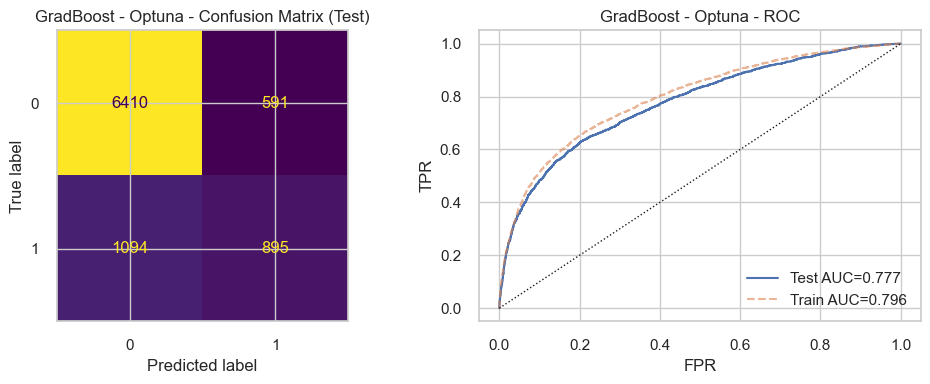

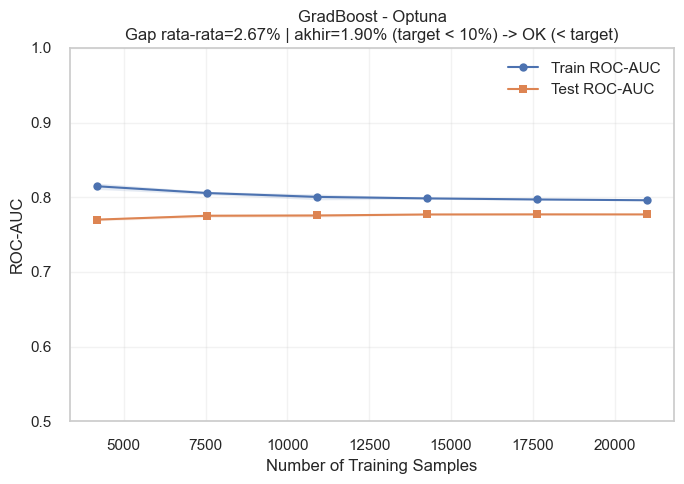

[Learning Curve] GradBoost - Optuna | gap rata-rata=2.67% | gap akhir=1.90% | target < 10% -> OK (< target)


Pipeline(memory=None,
         steps=[('resampler',
                 SMOTE(k_neighbors=5, random_state=42, sampling_strategy=0.5)),
                ('clf',
                 GradientBoostingClassifier(ccp_alpha=0.0,
                                            criterion='friedman_mse', init=None,
                                            learning_rate=0.010910404189497834,
                                            loss='log_loss', max_depth=4,
                                            max_features='sqrt',
                                            max_leaf_nodes=None,
                                            min_impurity_decrease=0.0,
                                            min_samples_leaf=99,
                                            min_samples_split=24,
                                            min_weight_fraction_leaf=0.0,
                                            n_estimators=389,
                                            n_iter_no_change=None,
                                            random_state=42,
                                            subsample=0.6434743092540163,
                                            tol=0.0001, validation_fraction=0.1,
                                            verbose=0, warm_start=False))],
         transform_input=None, verbose=False)

In [80]:
print(f'Best objective (AUC - penalti gap): {round(study_gb.best_value, 4)}')
print(f'Best Params: {study_gb.best_trial.params}')

evaluate_model_main('GradBoost - Optuna', gb_optuna(), lc=True, factory=gb_optuna)


In [32]:
gb_optuna_model = GradientBoostingClassifier(random_state=42, **study_gb.best_trial.params)

##### BayessianSearch

In [ ]:
params_bayes = {
    'clf__n_estimators'     : Integer(100, 400),
    'clf__learning_rate'    : Real(0.01, 0.1, prior='log-uniform'),
    'clf__max_depth'        : Integer(2, 4),
    'clf__subsample'        : Real(0.6, 0.9, prior='uniform'),
    'clf__min_samples_split': Integer(10, 50),
    'clf__min_samples_leaf' : Integer(30, 150),
    'clf__max_features'     : Categorical(['sqrt', 'log2'])
}

# 2. Pipeline dasar: sampler terpilih + GBM (resampling per-fold, bebas leakage)
gb_pipe_base = ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                            ('clf', GradientBoostingClassifier(random_state=42))])

# 3. Membangun BayesSearchCV di atas pipeline
bayes_search = BayesSearchCV(
    estimator=gb_pipe_base,
    search_spaces=params_bayes,
    n_iter=50,              
    cv=cv,                  
    scoring='roc_auc',
    n_jobs=-1,              
    random_state=42,
    verbose=1               
)
bayes_search.fit(X_train_processed, y_train)


In [ ]:
def gb_bayes():
    pipe = ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                        ('clf', GradientBoostingClassifier(random_state=42))])
    pipe.set_params(**bayes_search.best_params_)
    return pipe

gb_bayes_model = gb_bayes()


In [ ]:
print(f"\nBest CV AUC: {round(bayes_search.best_score_, 4)}")
print(f"Best Params: {dict(bayes_search.best_params_)}")

# Factory dan evaluasi menggunakan parameter terbaik
evaluate_model_main('GradBoost - BayesSearch', gb_bayes(), lc=True, factory=gb_bayes)


### LightGBM Classifier

##### Optuna

In [34]:
from lightgbm import LGBMClassifier
from sklearn.base import clone
import optuna

def objective_lgbm(trial):
    # Ruang pencarian diregularisasi (depth dangkal, leaves dibatasi, subsample, & L1/L2) demi gap kecil
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 400),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 2, 5),
        # num_leaves idealnya lebih kecil dari 2^max_depth untuk mencegah overfitting
        'num_leaves'        : trial.suggest_int('num_leaves', 7, 31), 
        'subsample'         : trial.suggest_float('subsample', 0.6, 0.9),
        'subsample_freq'    : trial.suggest_int('subsample_freq', 1, 5), # Wajib ada agar 'subsample' bekerja di LightGBM
        'min_child_samples' : trial.suggest_int('min_child_samples', 30, 150), # Pengganti min_samples_leaf
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0), # Pengganti max_features
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True), # L1 Regularization ekstra
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True) # L2 Regularization ekstra
    }

    # Estimator dibungkus ImbPipeline: resampling hanya pada fold latih (bebas leakage),
    # verbose=-1 ditambahkan agar terminal tidak penuh dengan log bawaan LightGBM
    model = ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                         ('clf', LGBMClassifier(random_state=42, verbose=-1, **params))])

    sc = cross_validate(model, X_train_processed, y_train, cv=cv,
                        scoring='roc_auc', return_train_score=True, n_jobs=-1)
    
    auc_te = sc['test_score'].mean()
    auc_tr = sc['train_score'].mean()
    gap = auc_tr - auc_te
    
    # Maksimalkan AUC test, tetapi beri penalti bila gap melebihi target generalisasi
    return auc_te - GAP_PENALTY * max(0.0, gap - GAP_TARGET)

# Membangun study Optuna
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/80 [00:00<?, ?it/s]

In [35]:
def lgbm_optuna():
    # Factory function untuk membuat ulang model dengan parameter terbaik
    return ImbPipeline([('resampler', clone(IMB_SAMPLER)),
                        ('clf', LGBMClassifier(random_state=42, verbose=-1, **study_lgbm.best_trial.params))])

lgbm_optuna_model = lgbm_optuna()

Best objective (AUC - penalti gap): 0.7835
Best Params: {'n_estimators': 206, 'learning_rate': 0.022703416859188776, 'max_depth': 4, 'num_leaves': 16, 'subsample': 0.6053937642080603, 'subsample_freq': 2, 'min_child_samples': 149, 'colsample_bytree': 0.9994651846172269, 'reg_alpha': 0.007300358083644766, 'reg_lambda': 7.7605215470378734}

=== LightGBM - Optuna ===
  AUC Train : 0.7994
  AUC CV    : 0.7835
  AUC Test  : 0.7779
  Gap Train-Test : 0.0215
  Gap CV-Test    : 0.0056
  Recall Train      : 0.4633
  Recall Test       : 0.4354
  Gap Recall (Tr-Te): 0.0279

Classification Report - LightGBM - Optuna (Test Data)
              precision    recall  f1-score   support

           0     0.8513    0.9182    0.8835      7001
           1     0.6018    0.4354    0.5053      1989

    accuracy                         0.8113      8990
   macro avg     0.7265    0.6768    0.6944      8990
weighted avg     0.7961    0.8113    0.7998      8990



,precision,recall,f1-score,support
0,0.851278,0.918155,0.883452,7001.000000
1,0.601807,0.435395,0.505251,1989.000000
accuracy,0.811346,0.811346,0.811346,0.811346
macro avg,0.726542,0.676775,0.694352,8990.000000
weighted avg,0.796084,0.811346,0.799777,8990.000000


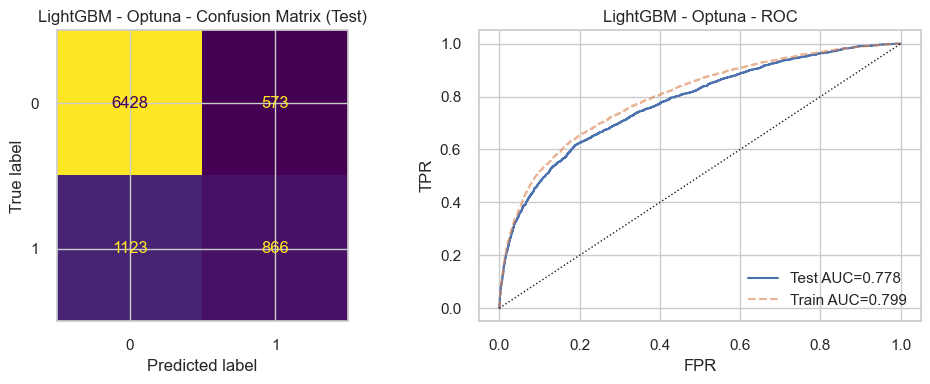

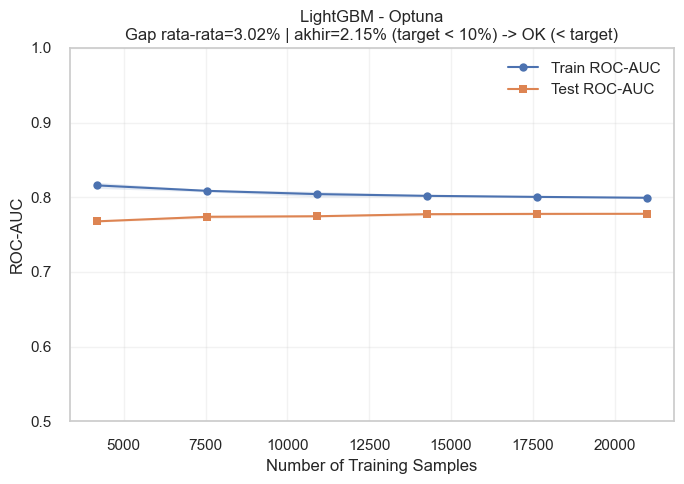

[Learning Curve] LightGBM - Optuna | gap rata-rata=3.02% | gap akhir=2.15% | target < 10% -> OK (< target)


Pipeline(memory=None,
         steps=[('resampler',
                 SMOTE(k_neighbors=5, random_state=42, sampling_strategy=0.5)),
                ('clf',
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=0.9994651846172269,
                                importance_type='split',
                                learning_rate=0.022703416859188776, max_depth=4,
                                min_child_samples=149, min_child_weight=0.001,
                                min_split_gain=0.0, n_estimators=206,
                                n_jobs=None, num_leaves=16, objective=None,
                                random_state=42, reg_alpha=0.007300358083644766,
                                reg_lambda=7.7605215470378734,
                                subsample=0.6053937642080603,
                                subsample_for_bin=200000, subsample_freq=2,
                                verbose=-1))],
         transform_input=None, verbose=False)

In [81]:
print(f'Best objective (AUC - penalti gap): {round(study_lgbm.best_value, 4)}')
print(f'Best Params: {study_lgbm.best_trial.params}')

# Evaluasi model
evaluate_model_main('LightGBM - Optuna', lgbm_optuna(), lc=True, factory=lgbm_optuna)

In [38]:
lgbm_optuna_model = LGBMClassifier(random_state=42, verbose=-1, **study_lgbm.best_trial.params)

## Step 14 — Validation Model

### GradientBoosting - Optuna

In [39]:
gb_optuna_val = gb_optuna_model
gb_optuna_val.fit(X_train_processed, y_train)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.010910404189497834, loss='log_loss',
                           max_depth=4, max_features='sqrt',
                           max_leaf_nodes=None, min_impurity_decrease=0.0,
                           min_samples_leaf=99, min_samples_split=24,
                           min_weight_fraction_leaf=0.0, n_estimators=389,
                           n_iter_no_change=None, random_state=42,
                           subsample=0.6434743092540163, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

##### Holdout Method

In [40]:
start_time = time.time()

# 1. Prediksi Probabilitas (untuk menghitung AUC)
y_pred_proba = gb_optuna_val.predict_proba(X_test_processed)[:, 1]

# 2. Prediksi Kelas Mutlak (untuk menghitung Akurasi, Precision, Recall, F1)
y_pred_class = gb_optuna_val.predict(X_test_processed)

# 3. Hitung Seluruh Skor Prediksi
holdout_auc  = roc_auc_score(y_test, y_pred_proba)
holdout_acc  = accuracy_score(y_test, y_pred_class)
holdout_prec = precision_score(y_test, y_pred_class)
holdout_rec  = recall_score(y_test, y_pred_class)
holdout_f1   = f1_score(y_test, y_pred_class)

print(f"Holdout ROC-AUC Score : {holdout_auc:.4f}")
print(f"Holdout Accuracy      : {holdout_acc:.4f}")
print(f"Holdout Precision     : {holdout_prec:.4f}")
print(f"Holdout Recall        : {holdout_rec:.4f}")
print(f"Holdout F1-Score      : {holdout_f1:.4f}")
print(f"Waktu komputasi       : {time.time() - start_time:.2f} detik\n")

Holdout ROC-AUC Score : 0.7796
Holdout Accuracy      : 0.8217
Holdout Precision     : 0.6821
Holdout Recall        : 0.3635
Holdout F1-Score      : 0.4743
Waktu komputasi       : 0.30 detik



##### Stratified K-Fold Method

In [41]:
start_time = time.time()

# Inisialisasi 5 lipatan (K=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Daftarkan semua metrik evaluasi prediksi yang ingin dihitung
scoring_metrics = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# Lakukan Cross-Validation sekaligus untuk semua metrik
cv_results = cross_validate(gb_optuna_val, X_train_processed, y_train, cv=skf, scoring=scoring_metrics, n_jobs=-1)

# Cetak Rata-rata Skor Prediksi dari ke-5 lipatan
print(f"Rata-rata K-Fold AUC       : {cv_results['test_roc_auc'].mean():.4f}")
print(f"Rata-rata K-Fold Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
print(f"Rata-rata K-Fold Precision : {cv_results['test_precision'].mean():.4f}")
print(f"Rata-rata K-Fold Recall    : {cv_results['test_recall'].mean():.4f}")
print(f"Rata-rata K-Fold F1-Score  : {cv_results['test_f1'].mean():.4f}")
print(f"Waktu komputasi            : {time.time() - start_time:.2f} detik\n")

Rata-rata K-Fold AUC       : 0.7843
Rata-rata K-Fold Accuracy  : 0.8199
Rata-rata K-Fold Precision : 0.6664
Rata-rata K-Fold Recall    : 0.3723
Rata-rata K-Fold F1-Score  : 0.4776
Waktu komputasi            : 24.83 detik



### LightGBM

In [42]:
lgbm_optuna_val = lgbm_optuna_model
lgbm_optuna_val.fit(X_train_processed, y_train)

LGBMClassifier(boosting_type='gbdt', class_weight=None,
               colsample_bytree=0.9994651846172269, importance_type='split',
               learning_rate=0.022703416859188776, max_depth=4,
               min_child_samples=149, min_child_weight=0.001,
               min_split_gain=0.0, n_estimators=206, n_jobs=None, num_leaves=16,
               objective=None, random_state=42, reg_alpha=0.007300358083644766,
               reg_lambda=7.7605215470378734, subsample=0.6053937642080603,
               subsample_for_bin=200000, subsample_freq=2, verbose=-1)

##### Holdout Method

In [43]:
start_time = time.time()

# 1. Prediksi Probabilitas (untuk menghitung AUC)
y_pred_proba = lgbm_optuna_val.predict_proba(X_test_processed)[:, 1]

# 2. Prediksi Kelas Mutlak (untuk menghitung Akurasi, Precision, Recall, F1)
y_pred_class = lgbm_optuna_val.predict(X_test_processed)

# 3. Hitung Seluruh Skor Prediksi
holdout_auc  = roc_auc_score(y_test, y_pred_proba)
holdout_acc  = accuracy_score(y_test, y_pred_class)
holdout_prec = precision_score(y_test, y_pred_class)
holdout_rec  = recall_score(y_test, y_pred_class)
holdout_f1   = f1_score(y_test, y_pred_class)

print(f"Holdout ROC-AUC Score : {holdout_auc:.4f}")
print(f"Holdout Accuracy      : {holdout_acc:.4f}")
print(f"Holdout Precision     : {holdout_prec:.4f}")
print(f"Holdout Recall        : {holdout_rec:.4f}")
print(f"Holdout F1-Score      : {holdout_f1:.4f}")
print(f"Waktu komputasi       : {time.time() - start_time:.2f} detik\n")

Holdout ROC-AUC Score : 0.7820
Holdout Accuracy      : 0.8207
Holdout Precision     : 0.6767
Holdout Recall        : 0.3630
Holdout F1-Score      : 0.4725
Waktu komputasi       : 0.09 detik



##### Stratified K-Fold Method

In [44]:
start_time = time.time()

# Inisialisasi 5 lipatan (K=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Daftarkan semua metrik evaluasi prediksi yang ingin dihitung
scoring_metrics = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# Lakukan Cross-Validation sekaligus untuk semua metrik
cv_results = cross_validate(lgbm_optuna_val, X_train_processed, y_train, cv=skf, scoring=scoring_metrics, n_jobs=-1)

# Cetak Rata-rata Skor Prediksi dari ke-5 lipatan
print(f"Rata-rata K-Fold AUC       : {cv_results['test_roc_auc'].mean():.4f}")
print(f"Rata-rata K-Fold Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
print(f"Rata-rata K-Fold Precision : {cv_results['test_precision'].mean():.4f}")
print(f"Rata-rata K-Fold Recall    : {cv_results['test_recall'].mean():.4f}")
print(f"Rata-rata K-Fold F1-Score  : {cv_results['test_f1'].mean():.4f}")
print(f"Waktu komputasi            : {time.time() - start_time:.2f} detik\n")

Rata-rata K-Fold AUC       : 0.7854
Rata-rata K-Fold Accuracy  : 0.8196
Rata-rata K-Fold Precision : 0.6671
Rata-rata K-Fold Recall    : 0.3685
Rata-rata K-Fold F1-Score  : 0.4746
Waktu komputasi            : 9.74 detik



## Step 15 — Evaluasi

#### LightGBM 

In [70]:
evaluate_model(lgbm_optuna_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [71]:
plot_model(lgbm_optuna_model, plot='auc', save=True)
plot_model(lgbm_optuna_model, plot='confusion_matrix', save=True)
plot_model(lgbm_optuna_model, plot='feature', save=True)
plot_model(lgbm_optuna_model, plot='class_report', save=True)

'Class Report.png'

#### GradientBoost

In [51]:
evaluate_model(gb_optuna_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [52]:
plot_model(gb_optuna_model, plot='auc', save=True)
plot_model(gb_optuna_model, plot='confusion_matrix', save=True)
plot_model(gb_optuna_model, plot='feature', save=True)
plot_model(gb_optuna_model, plot='class_report', save=True)

'Class Report.png'

## Step 16 — Finalisasi & Prediksi

In [72]:
best_model = gb_optuna_model

In [76]:
final_model = finalize_model(best_model)
predictions = predict_model(final_model, data=test_processed)
predictions.head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8259,0.7903,0.3705,0.7019,0.4850,0.3921,0.4211


,LIMIT_BAL,SEX,EDUCATION,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,AVG_UTIL_RATIO,AVG_PAY_AMT,N_LATE_PAYMENTS,MAX_DELAY,BILL_TREND,PAY_AMT_STD,MARRIAGE_2,DEFAULT,prediction_label,prediction_score
0,2.605236,0,2,0.902259,1.783428,0.138326,0.190883,2.018797,0.256596,0.913591,...,-0.520282,-0.047638,1.401508,1.168428,-0.038594,0.646179,0,0,0,0.6685
1,-0.679659,1,3,0.011005,0.107281,0.138326,0.190883,0.238541,0.256596,-0.213001,...,0.026423,-0.576243,-0.536348,-0.325903,0.511041,0.001126,0,0,0,0.8719
2,-1.070718,1,1,0.011005,0.107281,0.138326,1.915532,2.018797,2.007157,-0.374505,...,1.768697,-0.547031,1.401508,1.168428,-0.509923,-0.200754,0,1,0,0.5811
3,0.728153,1,1,0.011005,0.107281,1.824691,0.190883,0.238541,0.256596,1.695582,...,0.088646,0.323488,0.109604,1.168428,1.266513,1.013029,0,0,0,0.8197
4,-0.523236,0,2,1.793512,0.107281,0.138326,0.190883,0.238541,0.256596,0.931594,...,1.298546,-0.046908,0.109604,1.168428,0.187791,-1.062433,1,0,1,0.5977
5,-0.836083,1,2,0.011005,0.107281,0.138326,0.190883,0.238541,2.007157,0.299351,...,1.219942,-0.281467,0.109604,1.168428,0.648592,-0.335401,1,0,0,0.7810
6,-0.523236,0,2,1.793512,1.783428,1.824691,1.915532,2.018797,2.007157,0.469798,...,1.071089,-0.075655,3.339365,1.168428,-0.590727,0.062561,0,1,1,0.7943
7,-0.914295,1,2,0.011005,0.107281,0.138326,0.190883,-1.541714,-1.493965,-0.013279,...,0.188704,-0.909991,-0.536348,-0.325903,1.010790,-0.457467,1,1,0,0.8526
8,1.823118,1,4,-1.771502,-1.568866,-1.548039,-1.533766,-1.541714,-1.493965,-0.575799,...,-0.997547,1.318224,-0.536348,-1.820234,-0.088165,1.768002,0,0,0,0.9175
9,0.415306,1,1,0.011005,0.107281,0.138326,0.190883,0.238541,0.256596,-0.778547,...,-0.923168,-0.507196,-0.536348,-0.325903,-0.670805,-0.442750,0,0,0,0.8982


## Step 17 — Simpan Artefak Preprocessing & Model

Semua parameter yang "belajar" dari TRAIN disimpan agar **inference memakai transformasi yang persis sama** seperti training.

In [77]:
import joblib

final_columns = X_train_processed.columns.tolist()
sex_mapping = {int(c): int(label_encoder.transform([c])[0]) for c in label_encoder.classes_}

preprocessing_artifacts = {
    'fallback_education': int(fallback_education),
    'fallback_marriage':  int(fallback_marriage),
    'outlier_boundaries': outlier_boundaries,
    'sex_mapping': sex_mapping,
    'marriage_ohe_columns': marriage_ohe,
    'scaler': scaler,
    'columns_to_stdscaler': columns_to_stdscaler,
    'final_columns': final_columns,
    # Artefak KNN Imputation (dipakai ulang saat inferensi)
    'scaler_knn': scaler_knn,
    'knn_imputer': knn_imputer,
    'knn_feature_columns': knn_feature_columns,
    'knn_valid_ranges': valid_ranges,
    # Teknik imbalance yang terpilih otomatis (Step 11b)
    'imbalance_method': type(IMB_SAMPLER).__name__,
}
joblib.dump(preprocessing_artifacts, 'preprocessing_artifacts_V1.pkl')
save_model(final_model, 'best_credit_model_V1')
print('Artefak tersimpan. Teknik imbalance:', preprocessing_artifacts['imbalance_method'])
print('Kunci artefak:', list(preprocessing_artifacts.keys()))


Transformation Pipeline and Model Successfully Saved
Artefak tersimpan. Teknik imbalance: SMOTE
Kunci artefak: ['fallback_education', 'fallback_marriage', 'outlier_boundaries', 'sex_mapping', 'marriage_ohe_columns', 'scaler', 'columns_to_stdscaler', 'final_columns', 'scaler_knn', 'knn_imputer', 'knn_feature_columns', 'knn_valid_ranges', 'imbalance_method']


## Step 18 — Deployment (FastAPI)

`preprocess_for_inference` mereplikasi **urutan langkah yang sama** memakai artefak di atas, agar data mentah dari API ditransformasi identik dengan training sebelum diprediksi.

In [78]:
%%writefile app_fastapi1.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from pycaret.classification import load_model, predict_model
import pandas as pd
import numpy as np
import joblib
import uvicorn

app = FastAPI(title="Credit Risk API", description="API Prediksi Gagal Bayar Nasabah")

model = load_model('best_credit_model_V1')
artifacts = joblib.load('preprocessing_artifacts_V1.pkl')


def preprocess_for_inference(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

    # 1) PAY_0 -> PAY_1
    if 'PAY_0' in df.columns:
        df = df.rename(columns={'PAY_0': 'PAY_1'})

    # 2) Inkonsistensi EDUCATION/MARRIAGE -> tandai NaN lalu imputasi KNN (artefak dari TRAIN)
    df['EDUCATION'] = df['EDUCATION'].apply(lambda x: np.nan if x in [0, 5, 6] else x)
    df['MARRIAGE']  = df['MARRIAGE'].apply(lambda x: np.nan if x == 0 else x)

    knn_cols = artifacts['knn_feature_columns']
    df_knn = df.reindex(columns=knn_cols)                  # samakan kelengkapan & urutan kolom konteks
    scaled = artifacts['scaler_knn'].transform(df_knn)
    imputed = artifacts['knn_imputer'].transform(scaled)
    inv = pd.DataFrame(artifacts['scaler_knn'].inverse_transform(imputed),
                       columns=knn_cols, index=df.index)
    for col, (lo, hi) in artifacts['knn_valid_ranges'].items():
        df[col] = inv[col].round().clip(lo, hi)
    # Jaring pengaman bila masih ada NaN
    df['EDUCATION'] = df['EDUCATION'].fillna(artifacts['fallback_education']).astype(int)
    df['MARRIAGE']  = df['MARRIAGE'].fillna(artifacts['fallback_marriage']).astype(int)

    # 3) Outlier capping (batas TRAIN)
    for col, (lower, upper) in artifacts['outlier_boundaries'].items():
        df[col] = np.clip(df[col], lower, upper)

    # 4) Feature engineering
    bill_cols   = [f'BILL_AMT{i}' for i in range(1, 7)]
    payamt_cols = [f'PAY_AMT{i}'  for i in range(1, 7)]
    delay_cols  = [f'PAY_{i}'     for i in range(1, 7)]
    df['AVG_UTIL_RATIO']    = df[bill_cols].div(df['LIMIT_BAL'] + 1, axis=0).mean(axis=1)
    df['TOTAL_PAY_AMT']     = df[payamt_cols].sum(axis=1)
    df['AVG_PAY_AMT']       = df[payamt_cols].mean(axis=1)
    df['TOTAL_BILL_AMT']    = df[bill_cols].sum(axis=1)
    df['AVG_BILL_AMT']      = df[bill_cols].mean(axis=1)
    df['PAY_TO_BILL_RATIO'] = df['TOTAL_PAY_AMT'] / (df['TOTAL_BILL_AMT'] + 1)
    df['N_LATE_PAYMENTS']   = (df[delay_cols] > 0).sum(axis=1)
    df['MAX_DELAY']         = df[delay_cols].max(axis=1)
    df['BILL_TREND']        = df['BILL_AMT1'] - df['BILL_AMT6']
    df['PAY_AMT_STD']       = df[payamt_cols].std(axis=1).fillna(0)

    # 6
    # 5) OHE MARRIAGE
    df = pd.get_dummies(df, columns=['MARRIAGE'])
    for col in artifacts['marriage_ohe_columns']:
        if col not in df.columns:
            df[col] = 0

    # 6) Label encode SEX
    df['SEX'] = df['SEX'].map(artifacts['sex_mapping']).astype(int)

    # 7) Susun kolom final sesuai urutan training
    missing = [c for c in artifacts['final_columns'] if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom hilang setelah preprocessing: {missing}")
    df = df[artifacts['final_columns']]

    # 9) Scaling (hanya kolom kontinu)
    df[artifacts['columns_to_stdscaler']] = artifacts['scaler'].transform(
        df[artifacts['columns_to_stdscaler']])
    return df


class CreditInput(BaseModel):
    LIMIT_BAL: float; SEX: int; EDUCATION: int; MARRIAGE: int; AGE: int
    PAY_0: int; PAY_2: int; PAY_3: int; PAY_4: int; PAY_5: int; PAY_6: int
    BILL_AMT1: float; BILL_AMT2: float; BILL_AMT3: float
    BILL_AMT4: float; BILL_AMT5: float; BILL_AMT6: float
    PAY_AMT1: float; PAY_AMT2: float; PAY_AMT3: float
    PAY_AMT4: float; PAY_AMT5: float; PAY_AMT6: float


@app.get("/")
def home():
    return {"message": "Sistem Risk Analysis Aktif"}


@app.post("/predict")
def predict_risk(data: CreditInput):
    try:
        raw = pd.DataFrame([data.dict()])
        processed = preprocess_for_inference(raw)
        pred = predict_model(model, data=processed)
        label = int(pred['prediction_label'].values[0])
        score = float(pred['prediction_score'].values[0])
        return {"prediction_label": label, "prediction_score": score,
                "status": "Default" if label == 1 else "Non-Default"}
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")


if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8077)

Writing app_fastapi1.py


---
### Penutup
Notebook ini menautkan **setiap langkah preprocessing dengan bukti dari EDA dan karakteristik resmi dataset**: anomali kategori (vs dokumentasi *"no missing values"*), kemencengan variabel uang, korelasi antar bulan, dan ketimpangan kelas. Perbaikan utama dari versi awal: penghitungan outlier yang tahan *re-run*, *cast* OHE ke integer, penghapusan `setup()` ganda, serta penegasan **SMOTE per-fold** (bukan pada seluruh data) untuk estimasi performa yang jujur.